In [2]:
%load_ext autoreload
%autoreload 2
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import seaborn as sns
from pathlib import Path

# 1. Configuration des chemins (Chemin absolu de la racine)
root_path = os.path.abspath('.')
src_path = os.path.join(root_path, 'src')

# Ajout au système de recherche de Python
if root_path not in sys.path:
    sys.path.insert(0, root_path)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# 2. Résolution du conflit de nom pour le dossier 'config'
import config.config as cfg
sys.modules['config'] = cfg

# 3. Imports directs (sans filet, car tout est aligné)
from config.config import add_to_path, root_dir, google_folder_id, download_dir
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data



In [3]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=os.path.join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())

Extracted data found at: c:\Users\Utilisateur\Desktop\reading_seminar\Application données\Code\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24
Loading ARAG data from: c:\Users\Utilisateur\Desktop\reading_seminar\Application données\Code\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24


In [4]:
import random

def create_session_clean(data_dict, session_anomaly):
    """
    Create a list of clean session path
    """
    list_keys = list(data_dict.keys())

    # Find the list of clean session path
    session_clean = []
    for s in list_keys:
        df = data_dict[s].copy()
        if preprocessing.clean_dataframe(df).shape[0] != 0 and os.path.splitext(os.path.basename(s))[0] not in session_anomaly:
            session_clean.append(s)
    
    return session_clean


def split_session(session_clean, p=2/3, seed = None):
    """
    split the list of clean session path into train and test
    """
    if seed is not None:
        random.seed(seed)
    sessions = session_clean.copy()
    random.shuffle(sessions)
    n_train = int(len(sessions) * p)
    session_train = sessions[:n_train]
    session_test = sessions[n_train:]
    return session_train, session_test

def merge_dataset(data_dict, session):
    """ 
    Preprocess the session in the list session and concatenate to a single dataset
    """
    temp_list = []
    for s in session:
        df = data_dict[s].copy()
        df = preprocessing.clean_dataframe(df)
        df['session_id'] = os.path.splitext(os.path.basename(s))[0]
        temp_list.append(df)

    df_train = pd.concat(temp_list, ignore_index=True)
    return df_train

def create_dataset(data_dict, session_anomaly, split=False, p=2/3, seed=423):
    """
    Create the whole preprocessed dataset and remove the anomalous sessions. 

    data_dict (dict): The dictionnary containing all data
    session_anomaly (list): List of name of anomalous sessions
    split (bool): If True, split the dataset to train and test dataset
    p (int, 0<p<1): Ratio train/test
    seed (int): random seed for the split

    Return : 
    if split is False, return whole dataset and the session path list
    if split is True, return train dataset, test dataset and their session path list

    """
    #Create session clean list
    session_clean = create_session_clean(data_dict, session_anomaly)

    # if split is False, we will prerpocess all data
    session_train = session_clean 
    
    # Create train data session path list and test data session path list
    if split :
        session_train, session_test = split_session(session_clean, p, seed)
    
    # Create train dataset
    df_train = merge_dataset(data_dict, session_train)

    # Create test dataset
    if split:
        df_test = merge_dataset(data_dict, session_test)
        return df_train, df_test, session_train, session_test
        
    return df_train, session_train


In [5]:
#abnormal sessions from dynamic pca notebook
session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

In [9]:
# Les mêmes sessions test et trai  que pour les autoencodeurs
df_train, df_test, list_train1, list_test1= create_dataset(data_dict, session_anomaly,split=True,p=0.8, seed=40)

In [10]:
print(len(list_train1))
print(len(list_test1))

24
6


In [11]:
display(list_test1)


['c:\\Users\\Utilisateur\\Desktop\\reading_seminar\\Application données\\Code\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL3143.csv',
 'c:\\Users\\Utilisateur\\Desktop\\reading_seminar\\Application données\\Code\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL3052.csv',
 'c:\\Users\\Utilisateur\\Desktop\\reading_seminar\\Application données\\Code\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL2889.csv',
 'c:\\Users\\Utilisateur\\Desktop\\reading_seminar\\Application données\\Code\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL3358.csv',
 'c:\\Users\\Utilisateur\\Desktop\\reading_seminar\\Application données\\Code\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL3397.csv',
 'c:\\Users\\Utilisateur\\Desktop\\reading_seminar\\Application donnée

In [12]:
from anomaly_detection.deep_learning.isolation_forest import AnomalyDetectorIF

#Definte the columns coresponding to a sensor
features = [c for c in df_train.columns if c not in ['session_id', 'time_real', 'datetime', ]]

# Train the model with the train dataset
clf_if = AnomalyDetectorIF(contamination=0.01,max_samples=256)
clf_if.fit(df_train, features)

#Test the model on the test dataset
results_clean = clf_if.predict_anomalies(df_test)

# Test on filtered data 

In [13]:
print(f"Number of points notified as abnormal : {results_clean['anomaly_detected'].sum()}")
print(f"Percent : {results_clean['anomaly_detected'].mean() * 100:.2f}%")

Number of points notified as abnormal : 592
Percent : 1.03%


We trained the Isolation Forest with a 1% contamination rate (0.01), setting a strict threshold for baseline noise. When applying this exact same threshold to the test dataset, we get a  mean detection rate of 0.91%. This result perfectly matches our expectations: it confirms the model is correctly calibrated and successfully ignores normal background noise without triggering false alarms.

The following cell show the result of the Isolation forest algorithm on each session of the test dataset

### Test and print the result of the algorithm on each session of the test dataset

 Session : c:\Users\Utilisateur\Desktop\reading_seminar\Application données\Code\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3143.csv
Detection rate : 1.67%


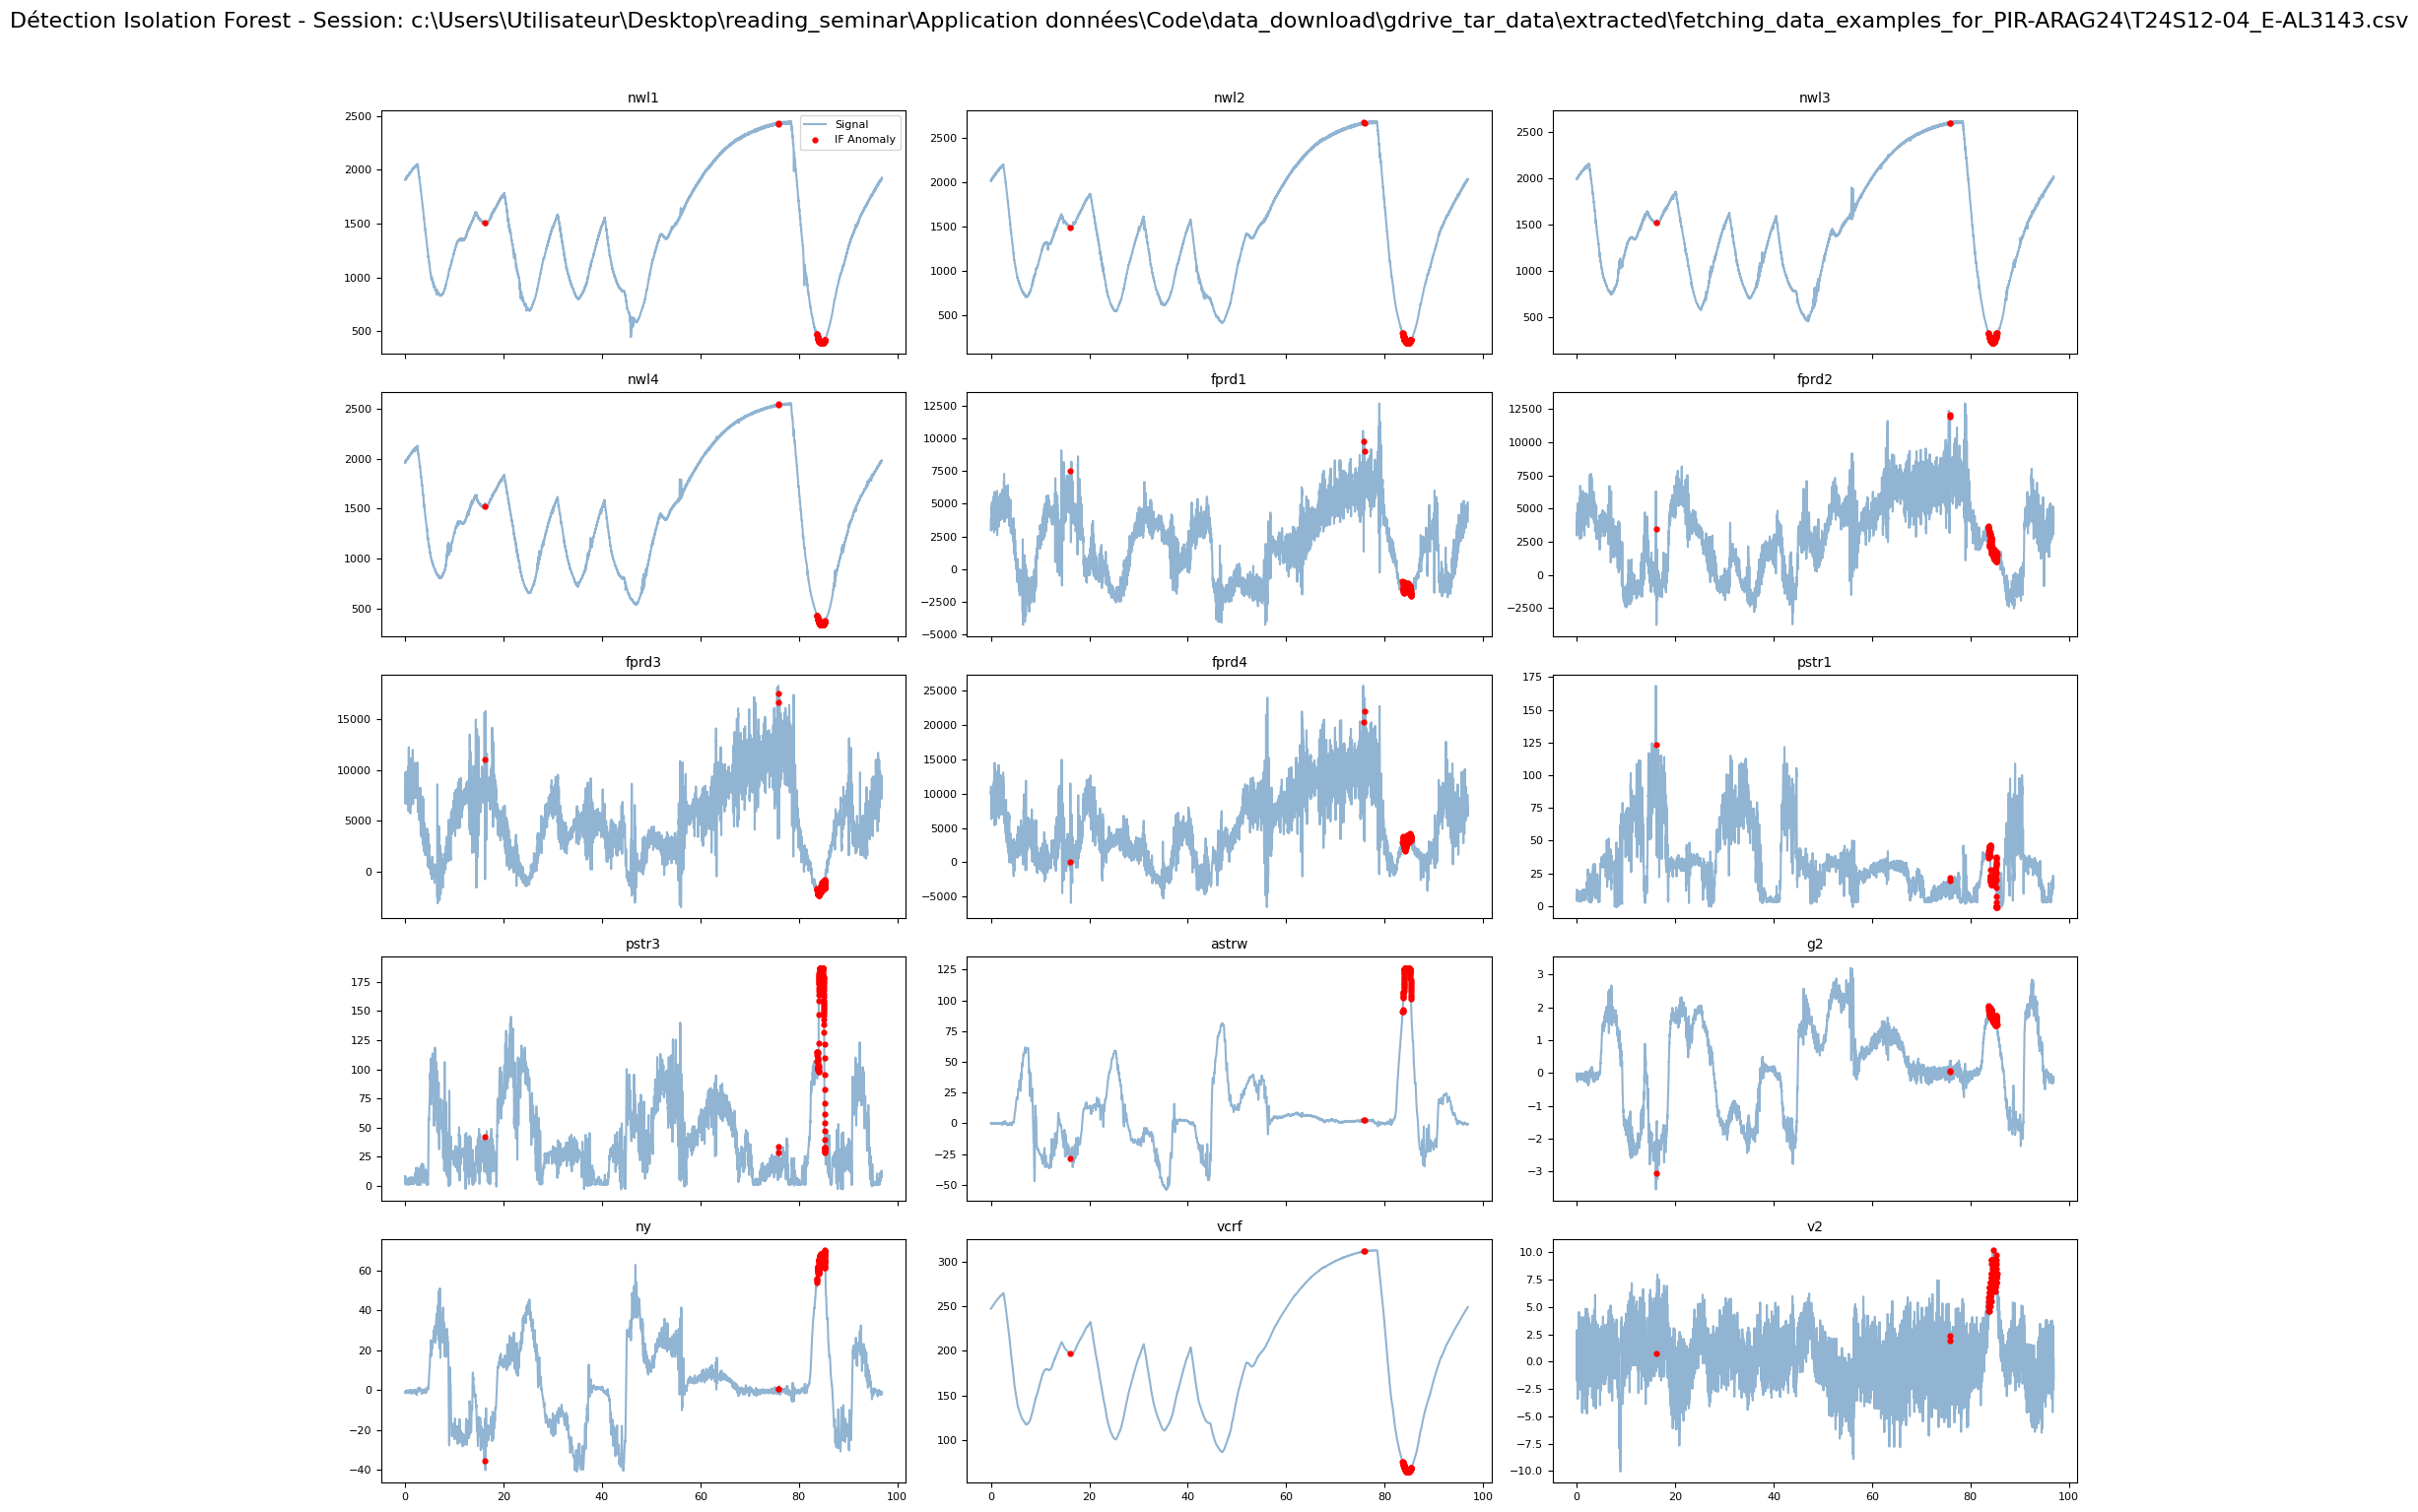

 Session : c:\Users\Utilisateur\Desktop\reading_seminar\Application données\Code\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3052.csv
Detection rate : 0.57%


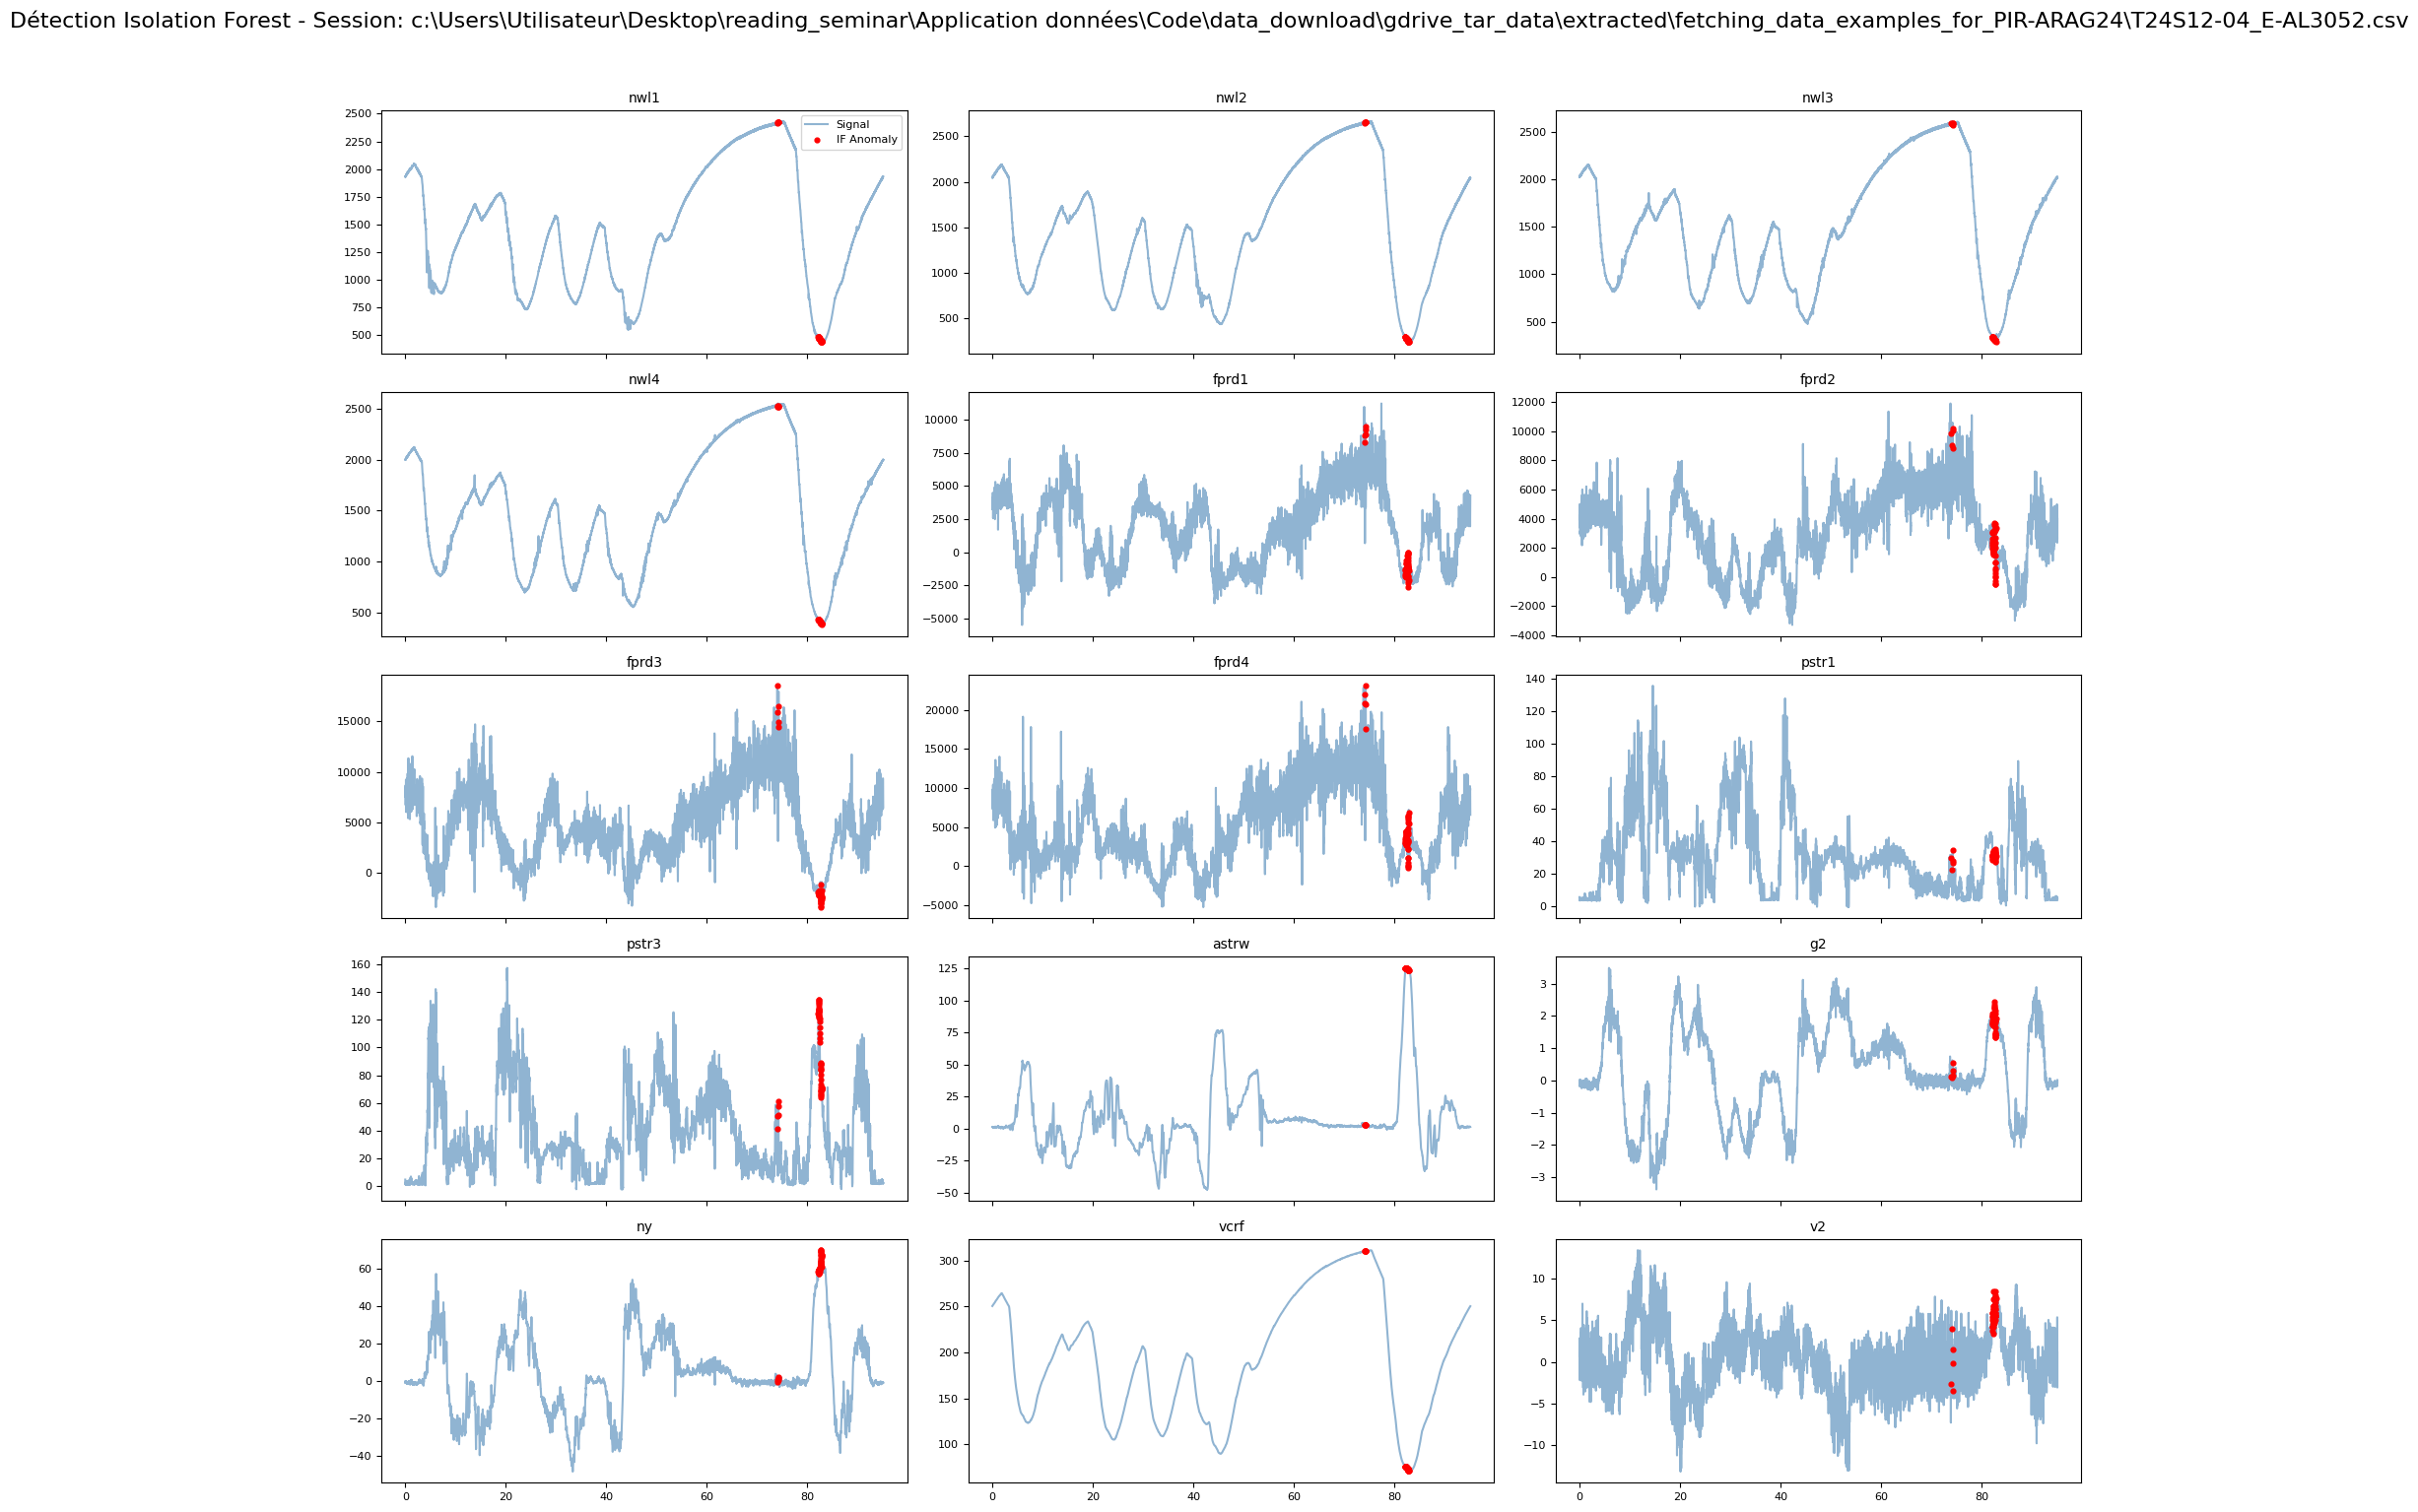

 Session : c:\Users\Utilisateur\Desktop\reading_seminar\Application données\Code\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL2889.csv
Detection rate : 0.93%


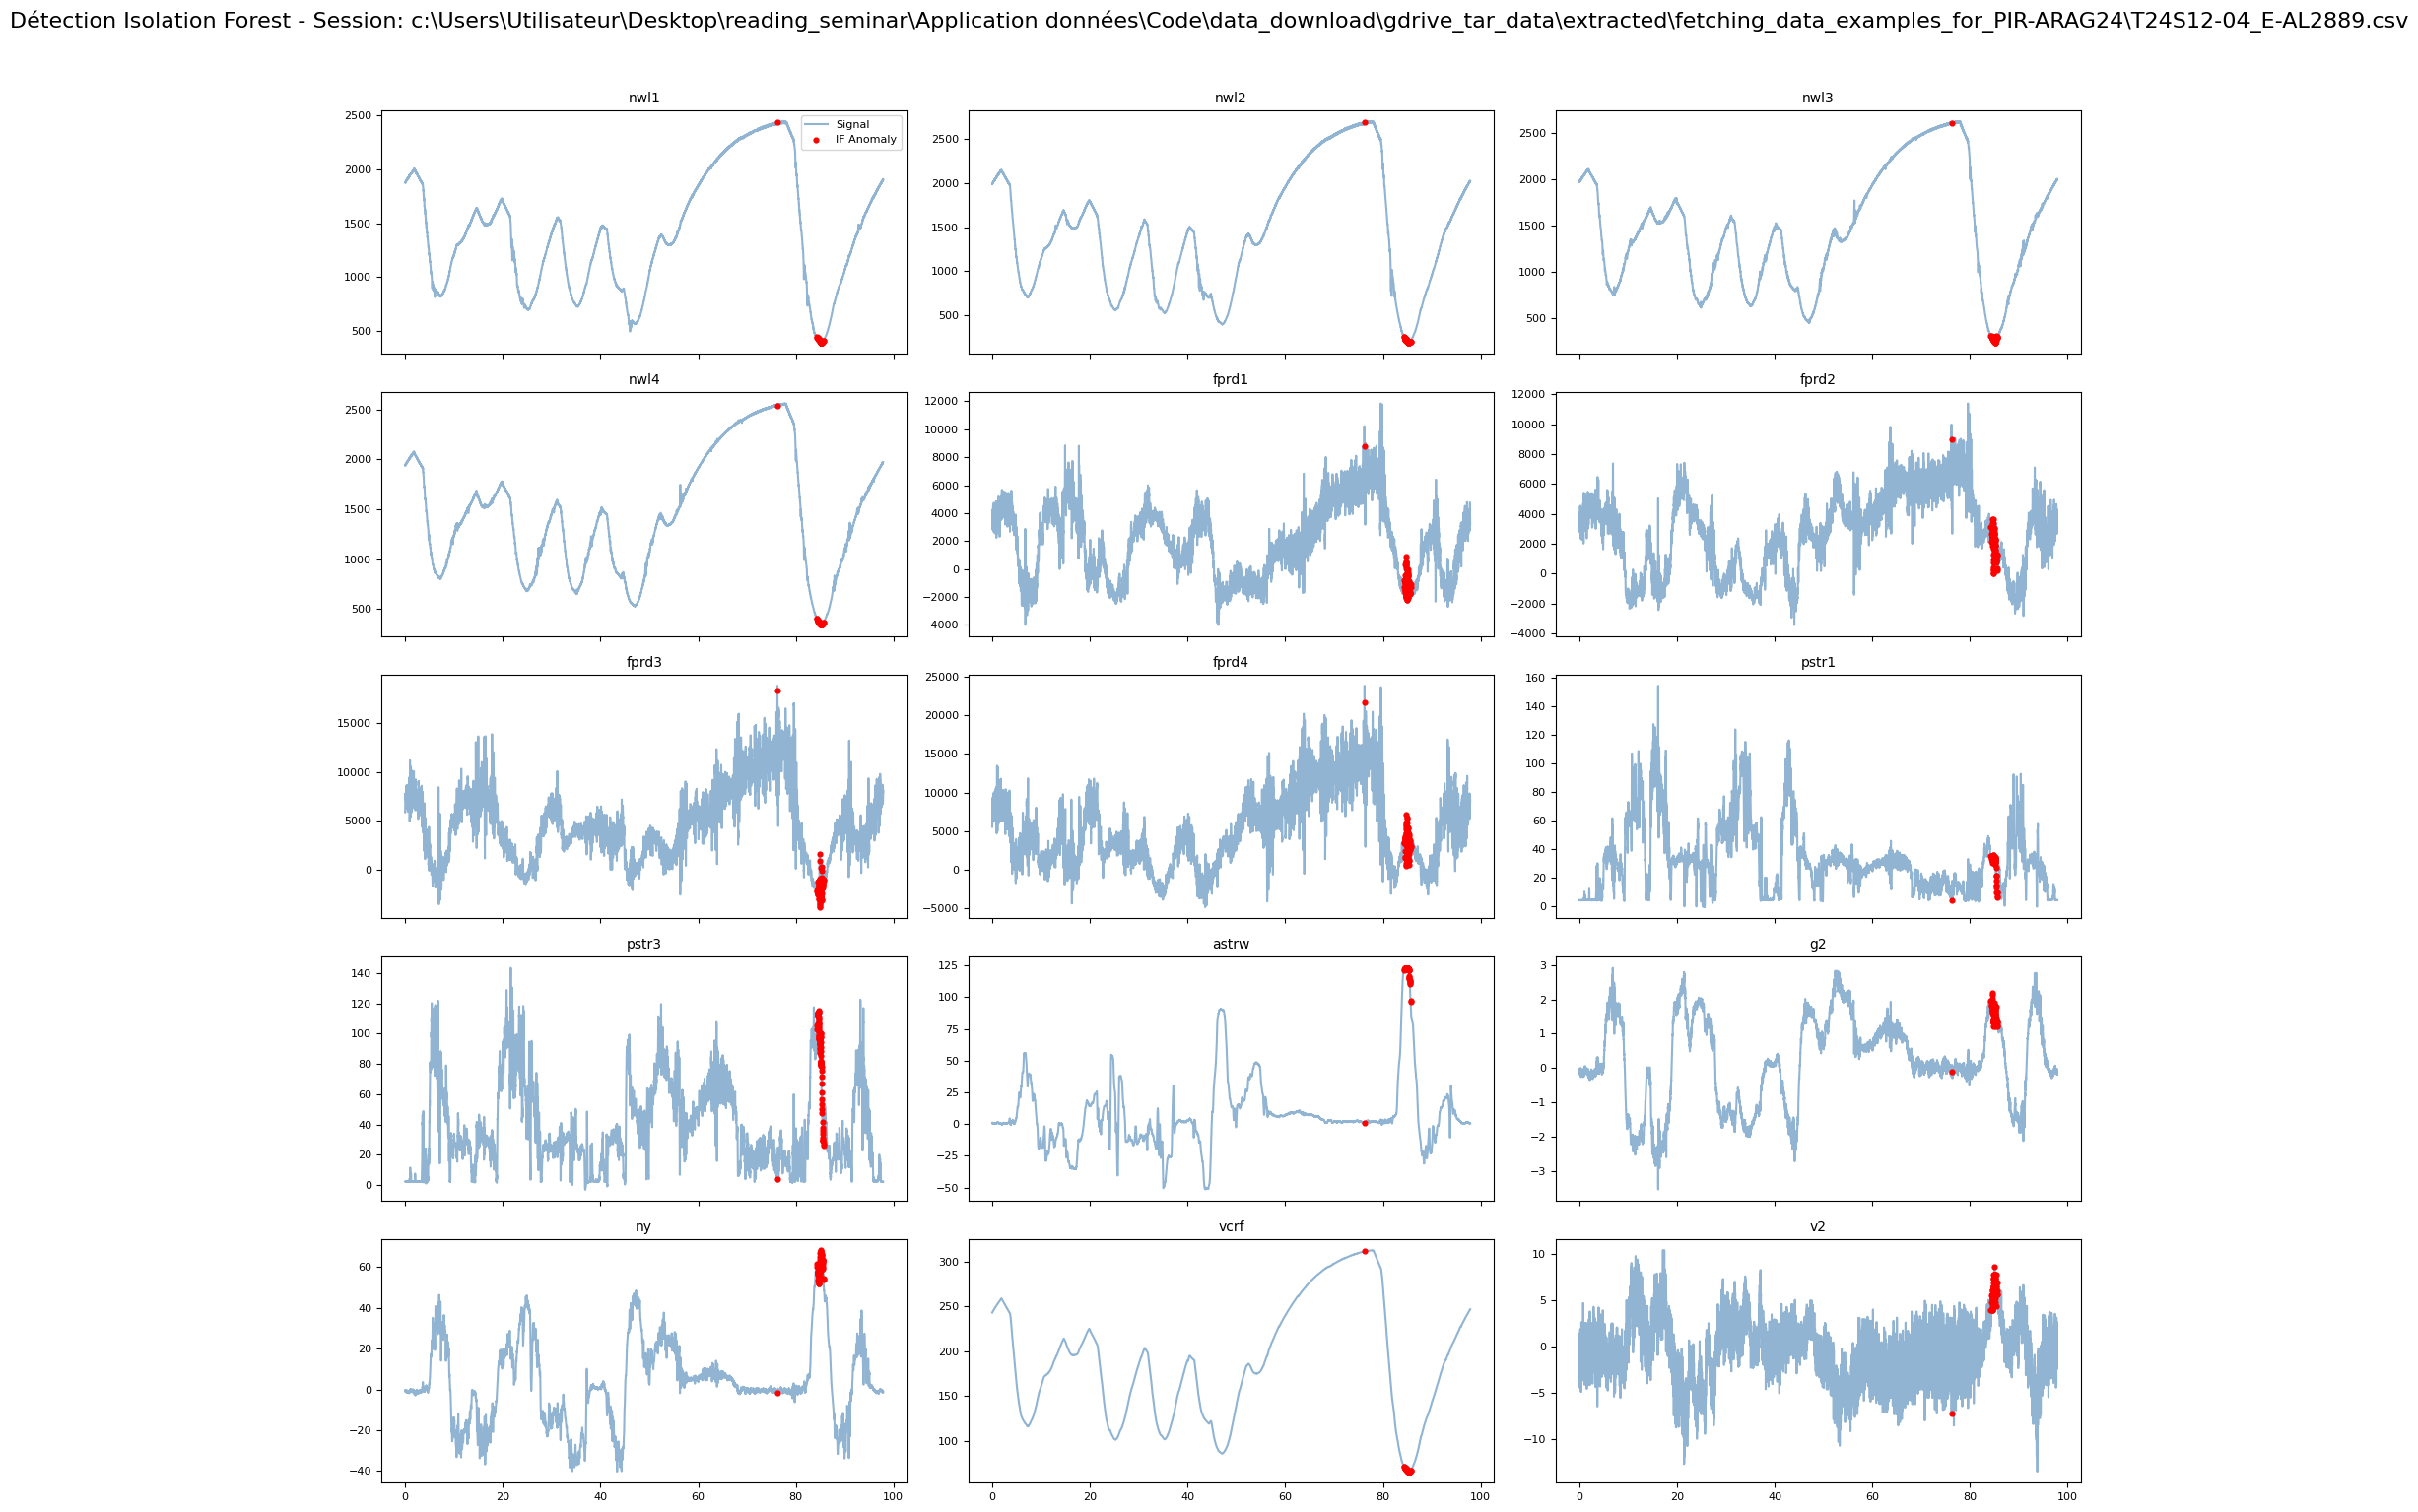

 Session : c:\Users\Utilisateur\Desktop\reading_seminar\Application données\Code\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3358.csv
Detection rate : 0.90%


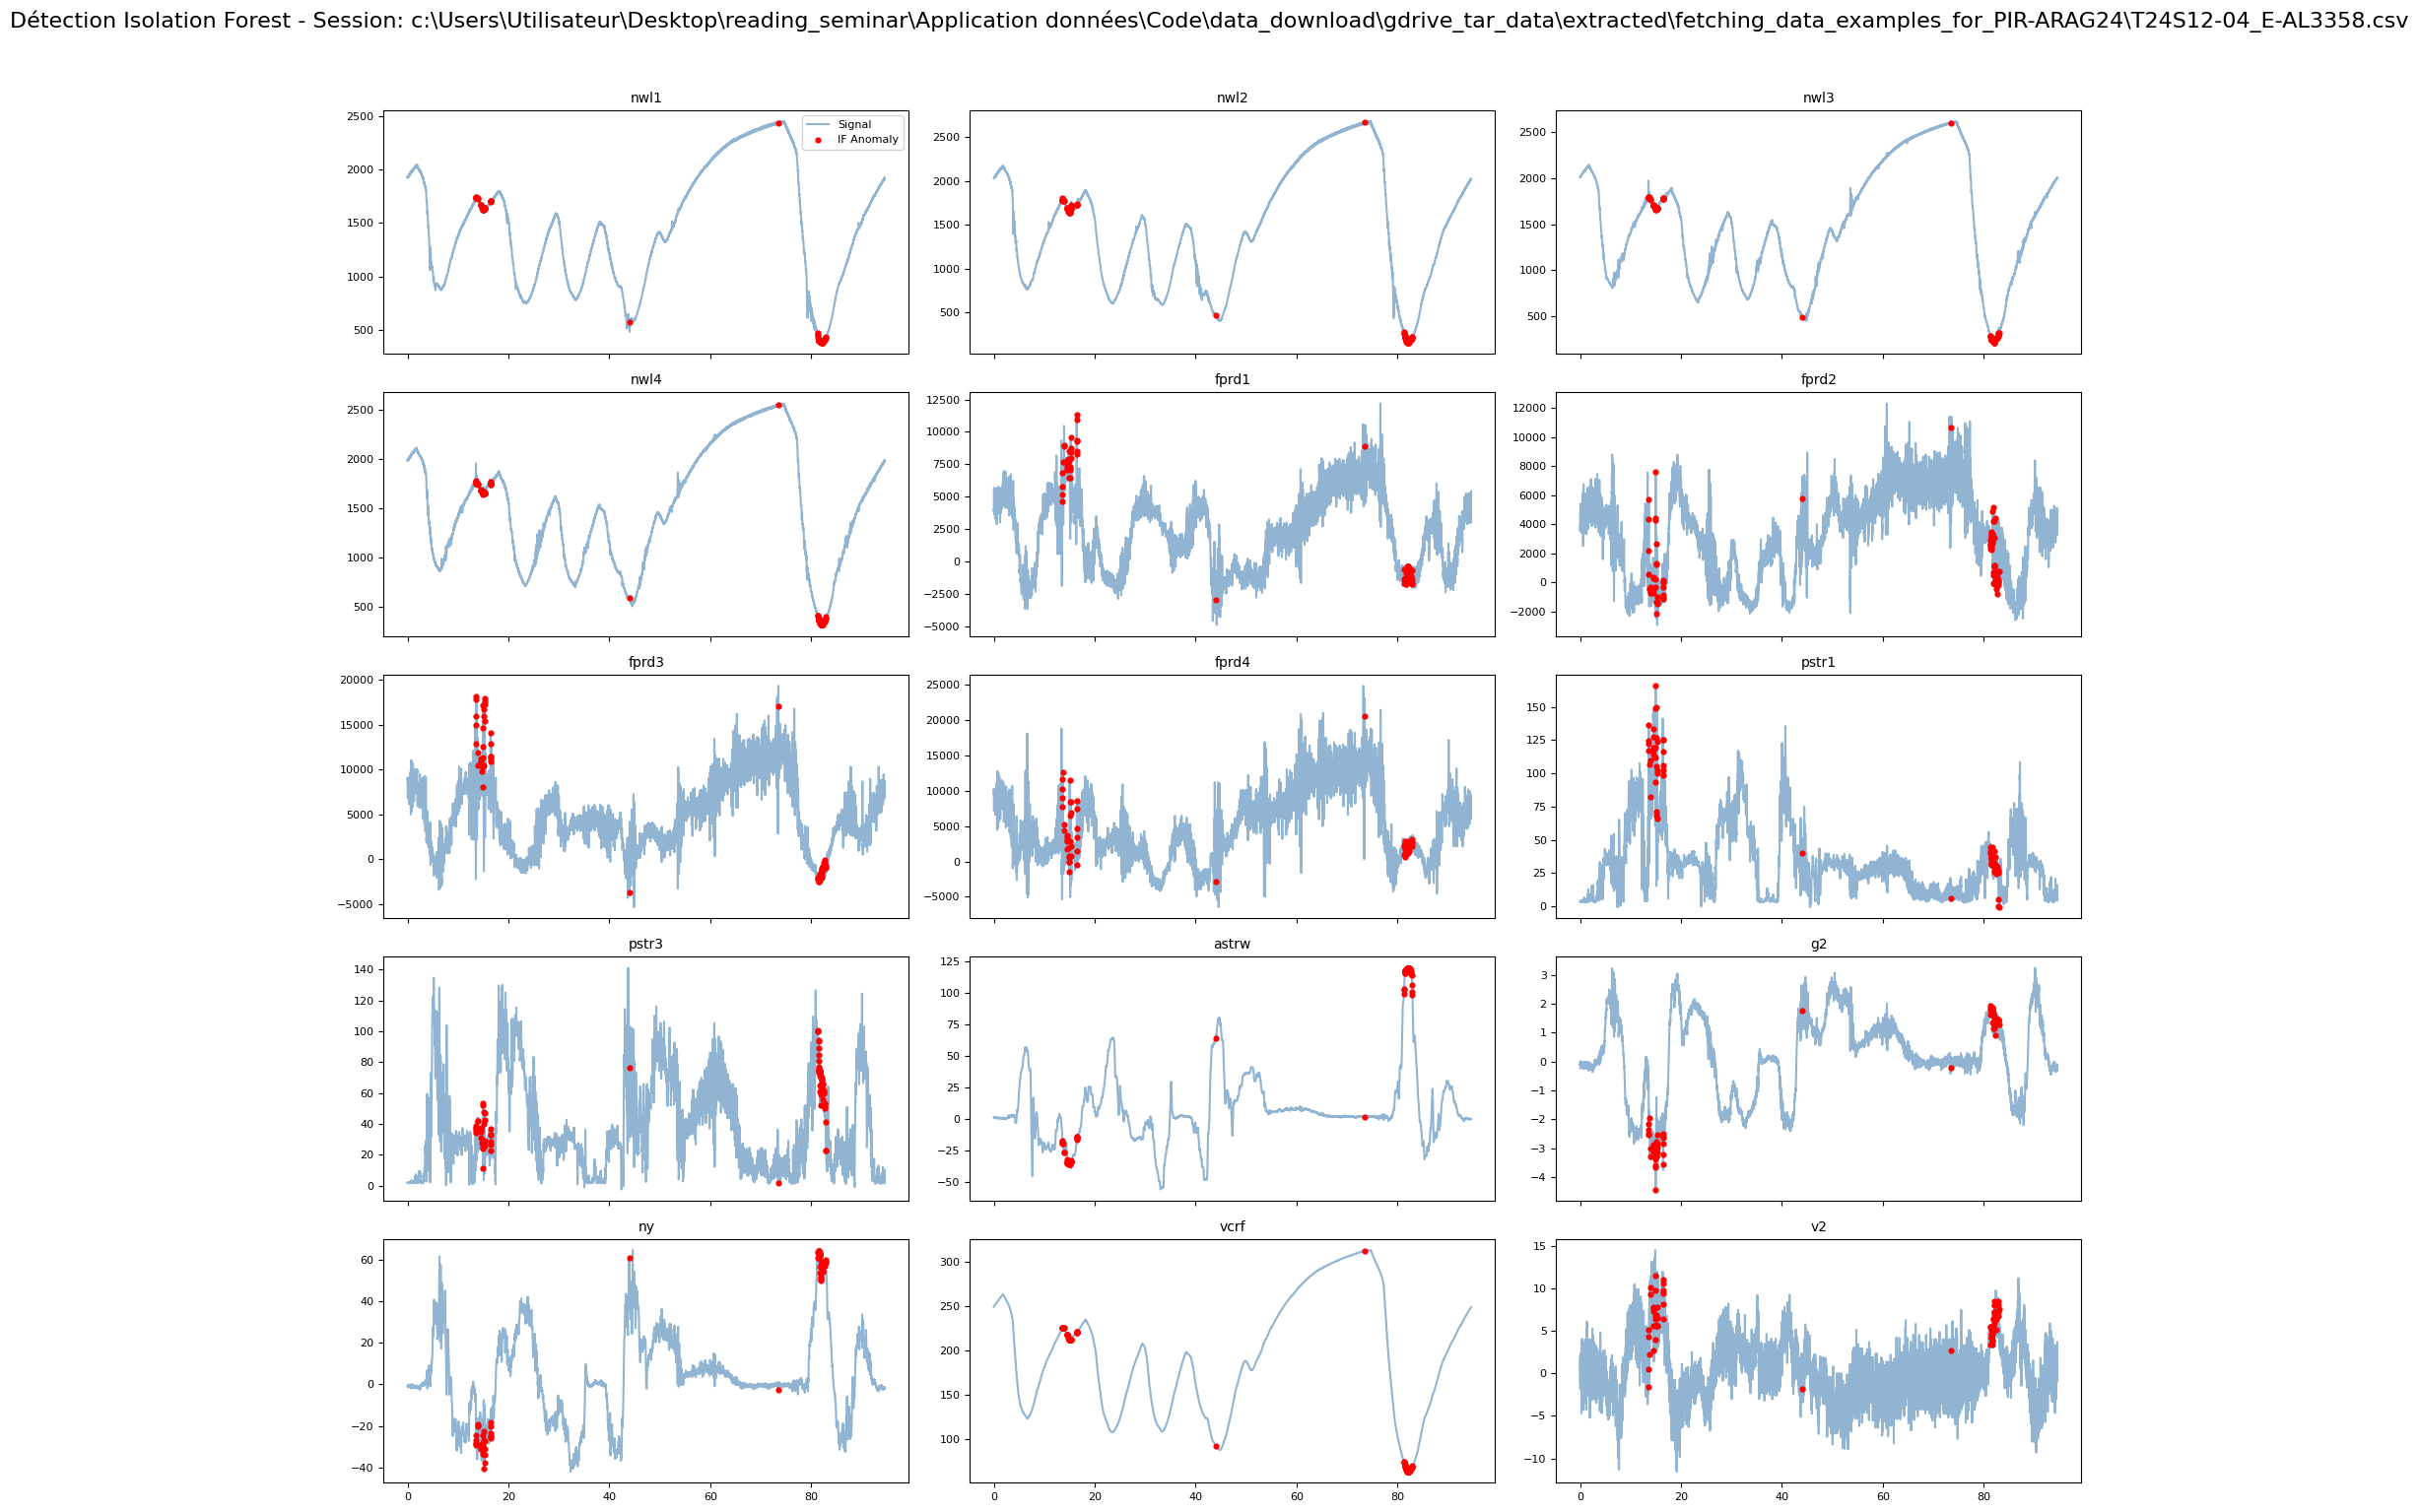

 Session : c:\Users\Utilisateur\Desktop\reading_seminar\Application données\Code\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3397.csv
Detection rate : 1.21%


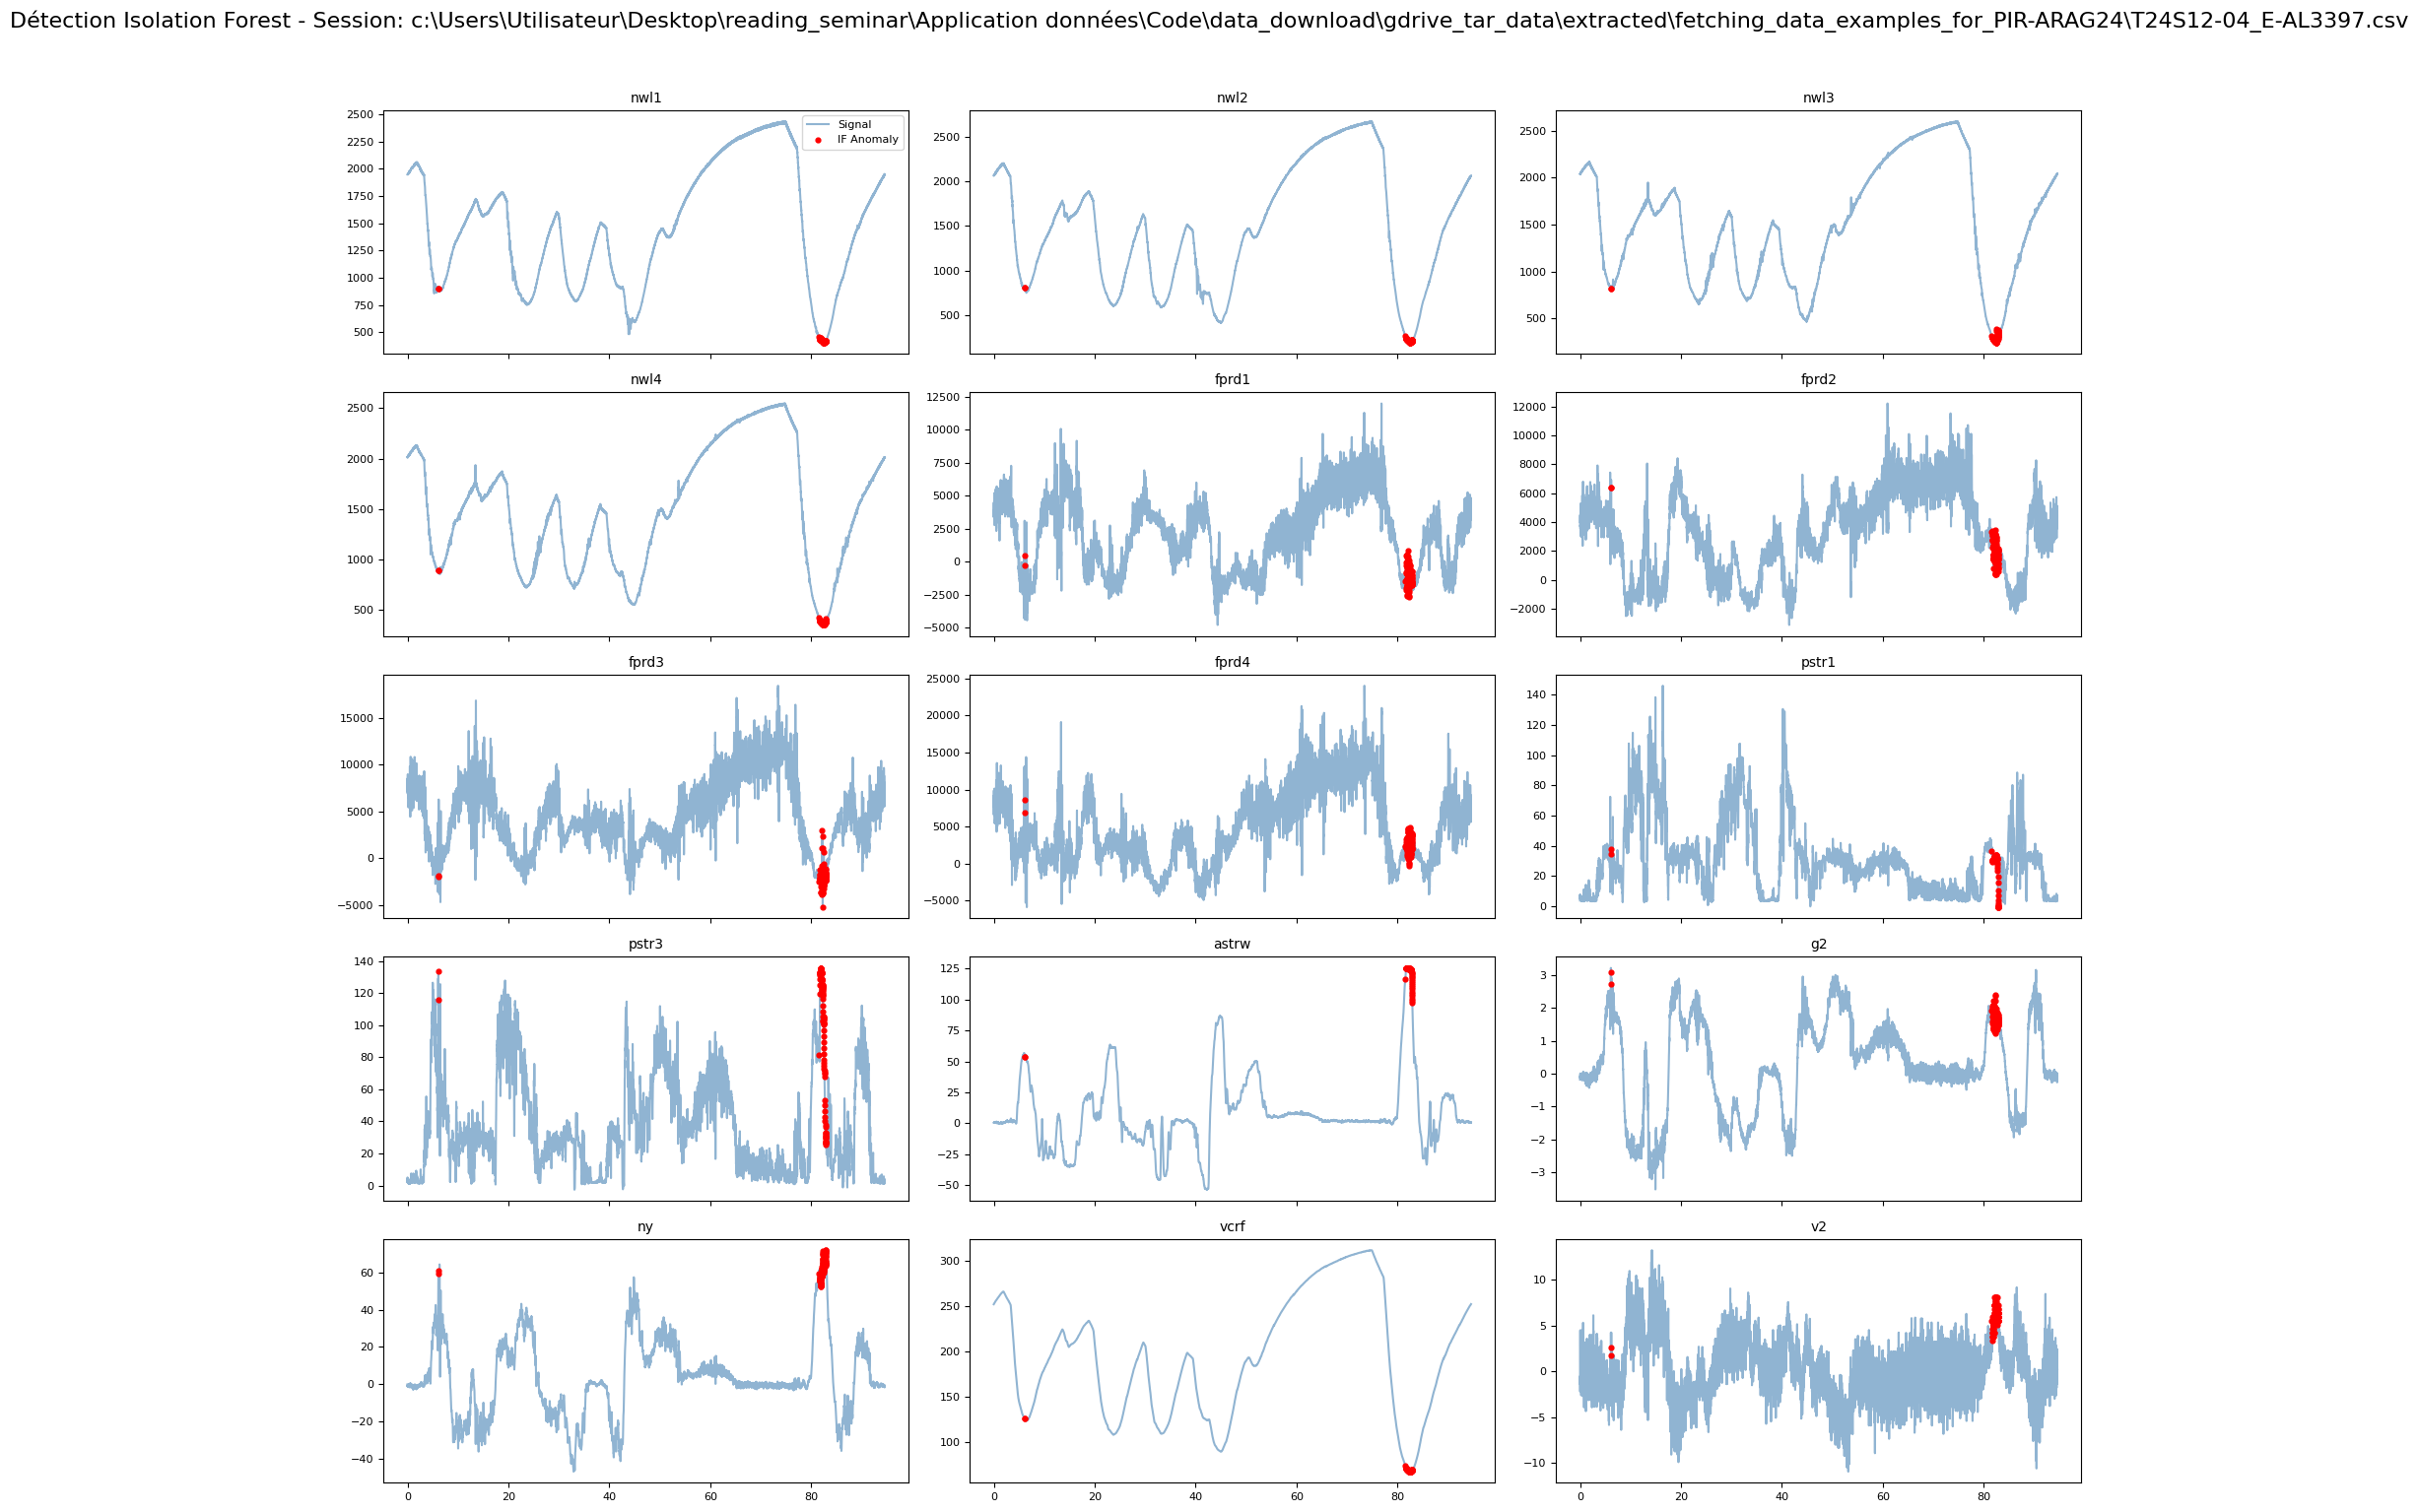

 Session : c:\Users\Utilisateur\Desktop\reading_seminar\Application données\Code\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3319.csv
Detection rate : 0.91%


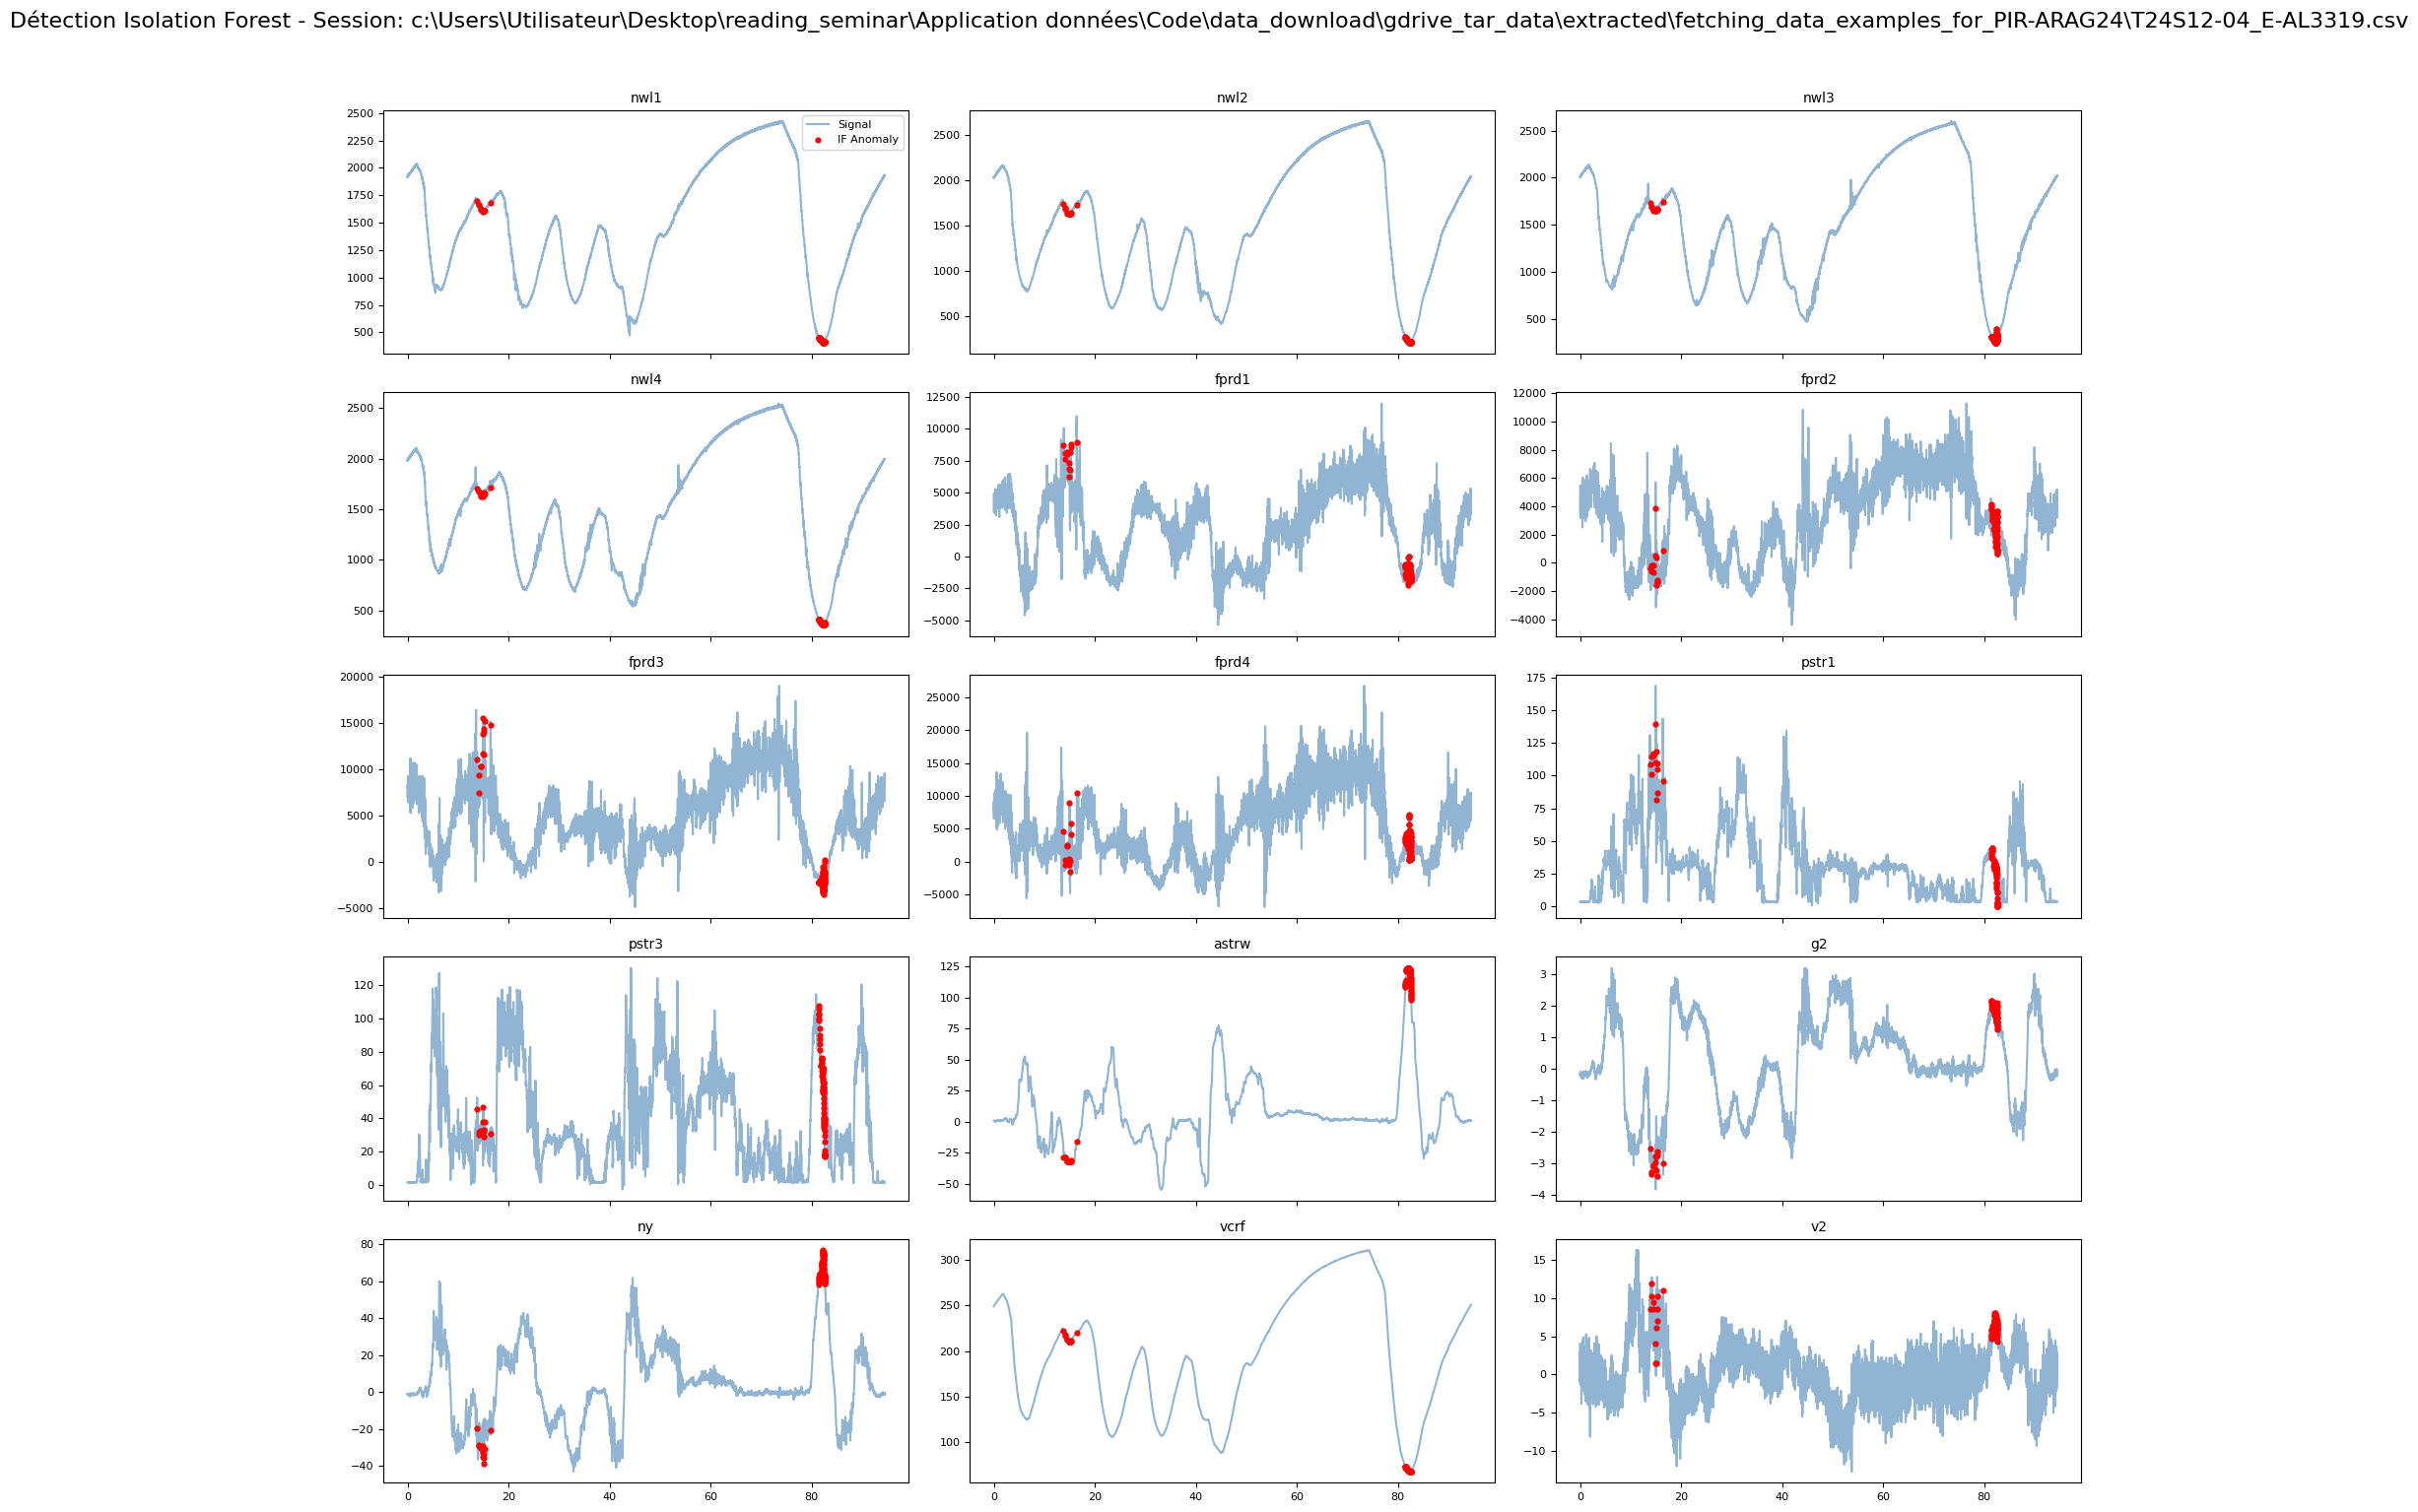

In [14]:
for name in list_test1:
    id_panne_complet = [k for k in data_dict.keys() if name in k][0]

    df_panne = data_dict[id_panne_complet].copy()
    df_panne = preprocessing.clean_dataframe(df_panne)
    results_panne = clf_if.predict_anomalies(df_panne)
    #Print the result
    print(f" Session : {name}")
    print(f"Detection rate : {results_panne['anomaly_detected'].mean() * 100:.2f}%")

    df_plot = results_panne.copy()
    anomaly_mask = df_plot['anomaly_detected'] == 1
    anomaly_times = df_plot.loc[anomaly_mask, 'time_real']

# Select only the sensors 
    cols_to_show = features[:15] 

    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 15), sharex=True)
    axes = axes.flatten()

    for i, col in enumerate(cols_to_show):
        ax = axes[i]
        
        # Draw the original signal
        ax.plot(df_plot['time_real'], df_plot[col], color='steelblue', alpha=0.6, label='Signal')

        # Overlay the anomaly points in red
        ax.scatter(
            anomaly_times,
            df_plot.loc[anomaly_mask, col],
            color='red',
            s=12,
            label='IF Anomaly',
            zorder=3
        )

        ax.set_title(f"{col}", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=8)
        if i == 0:
            ax.legend(loc="upper right", fontsize=8)


    plt.suptitle(f"Détection Isolation Forest - Session: {name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
#

## Detection on anomalous data

Here we test the algorithm on the anomalous sessions determindes by the PCA previously

 Session : T24S12-04_E-AL2706
Detection rate : 100.00%


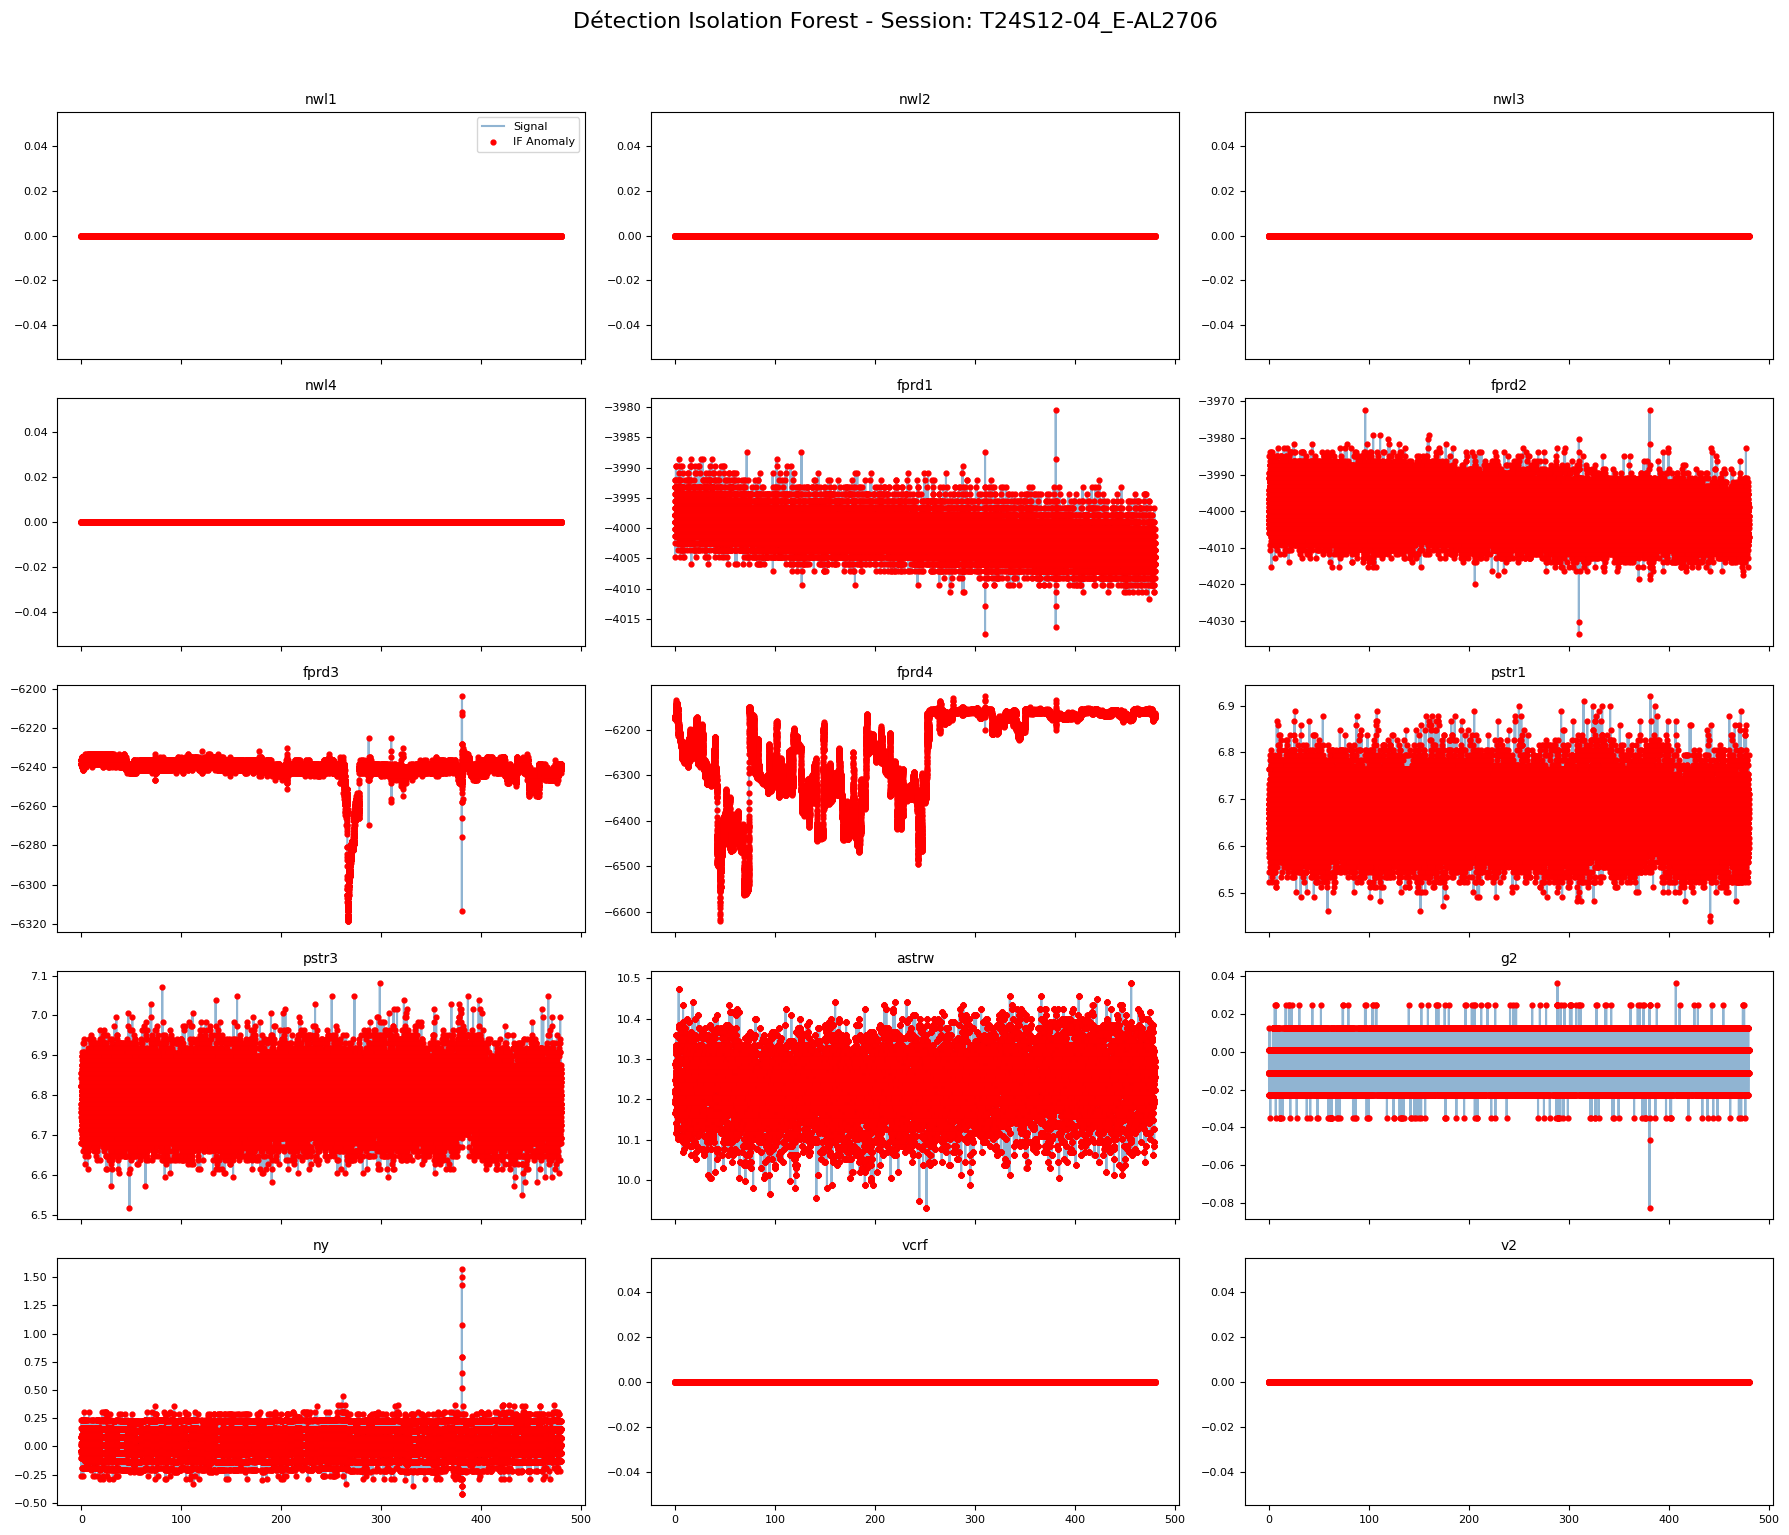

 Session : T24S12-04_E-AL2725
Detection rate : 90.50%


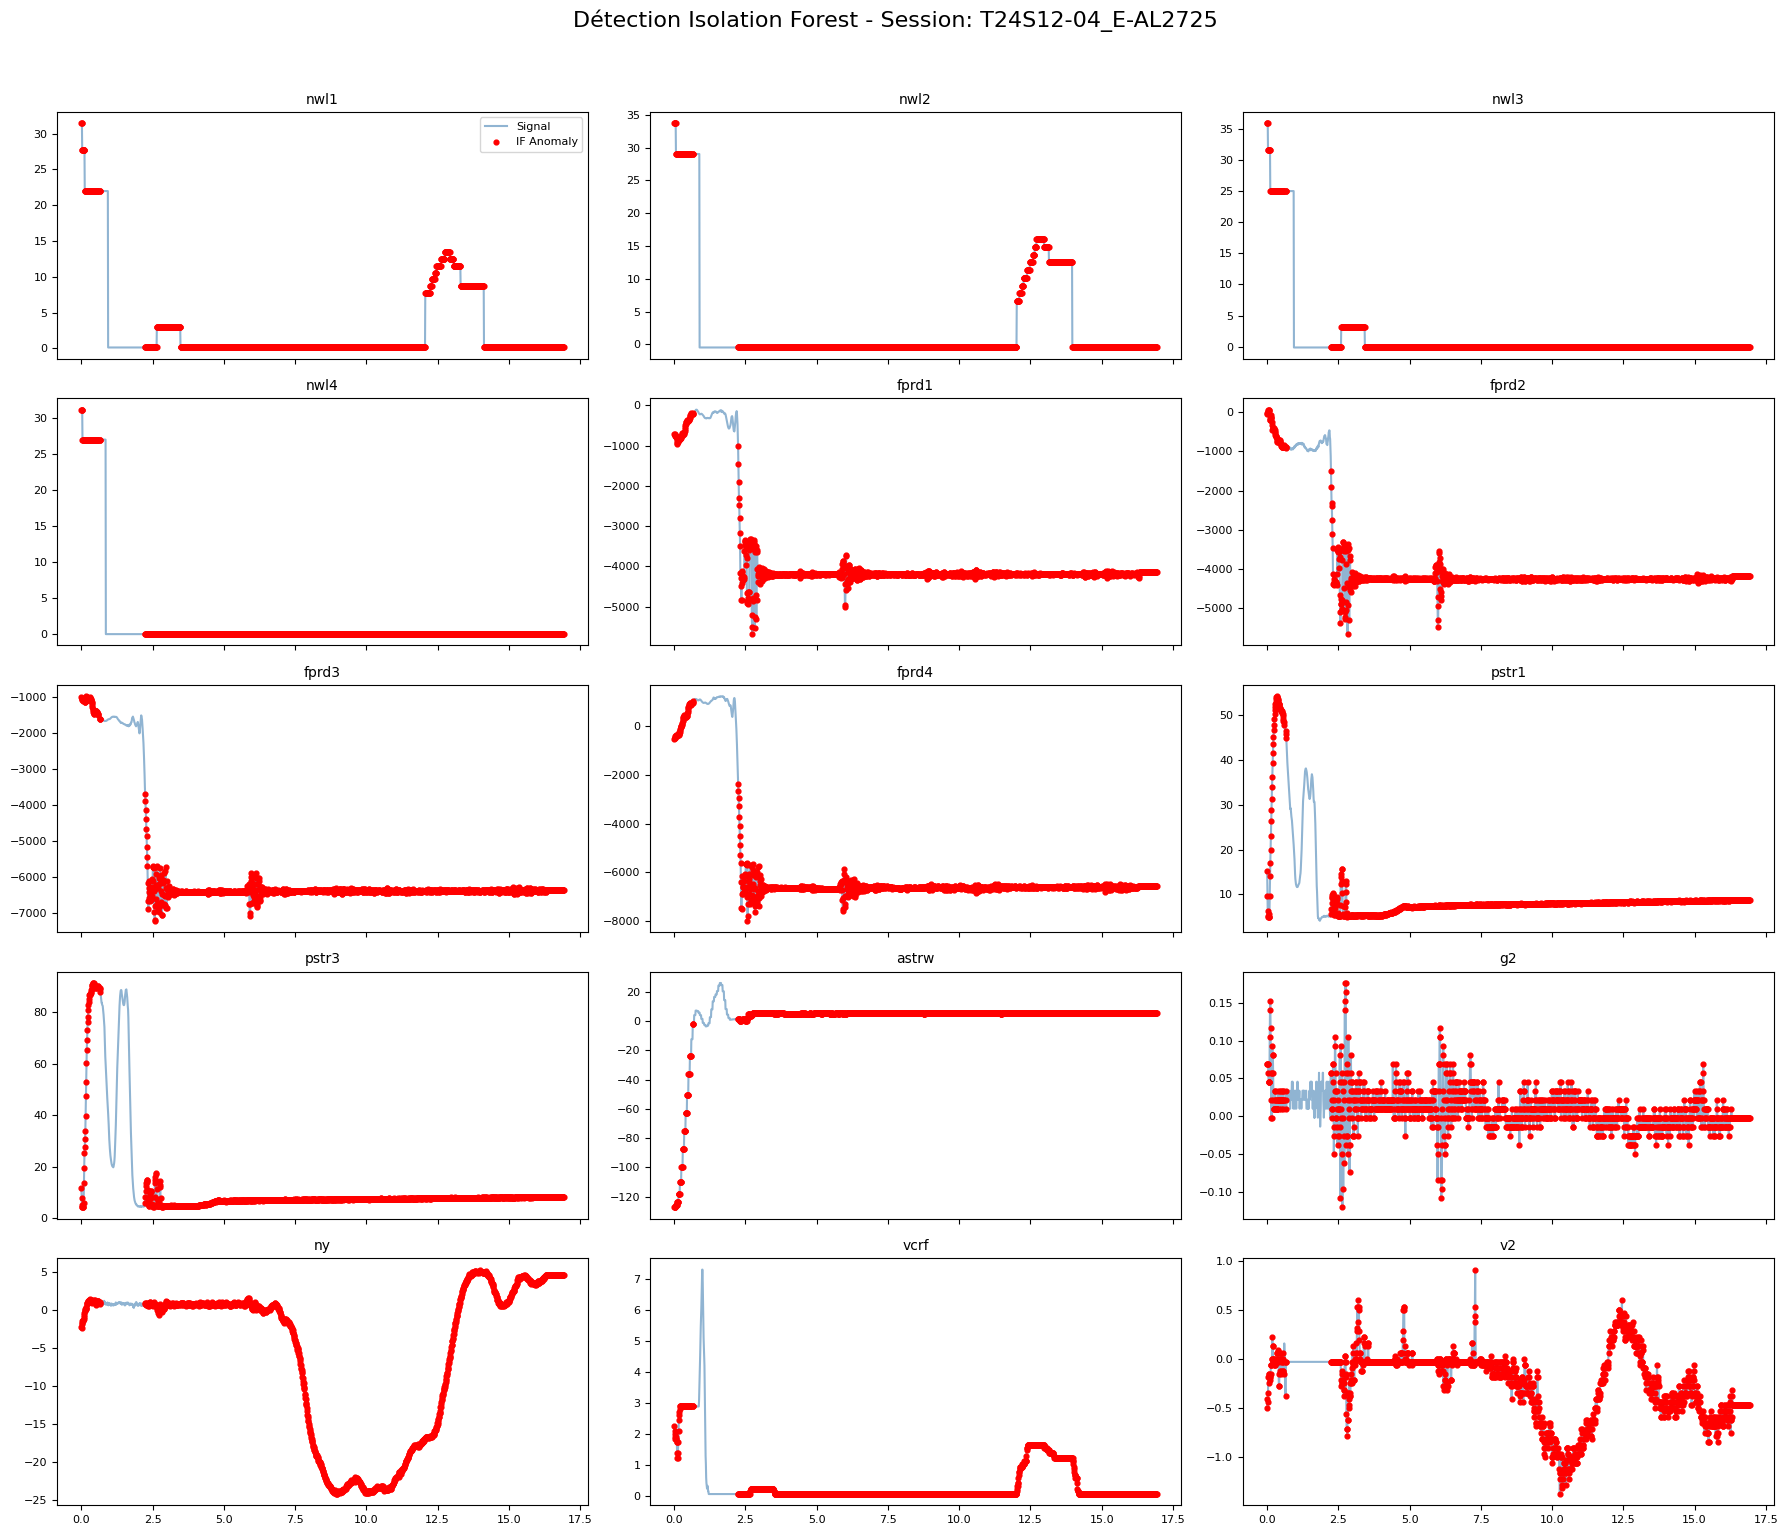

 Session : T24S12-04_E-AL2761
Detection rate : 100.00%


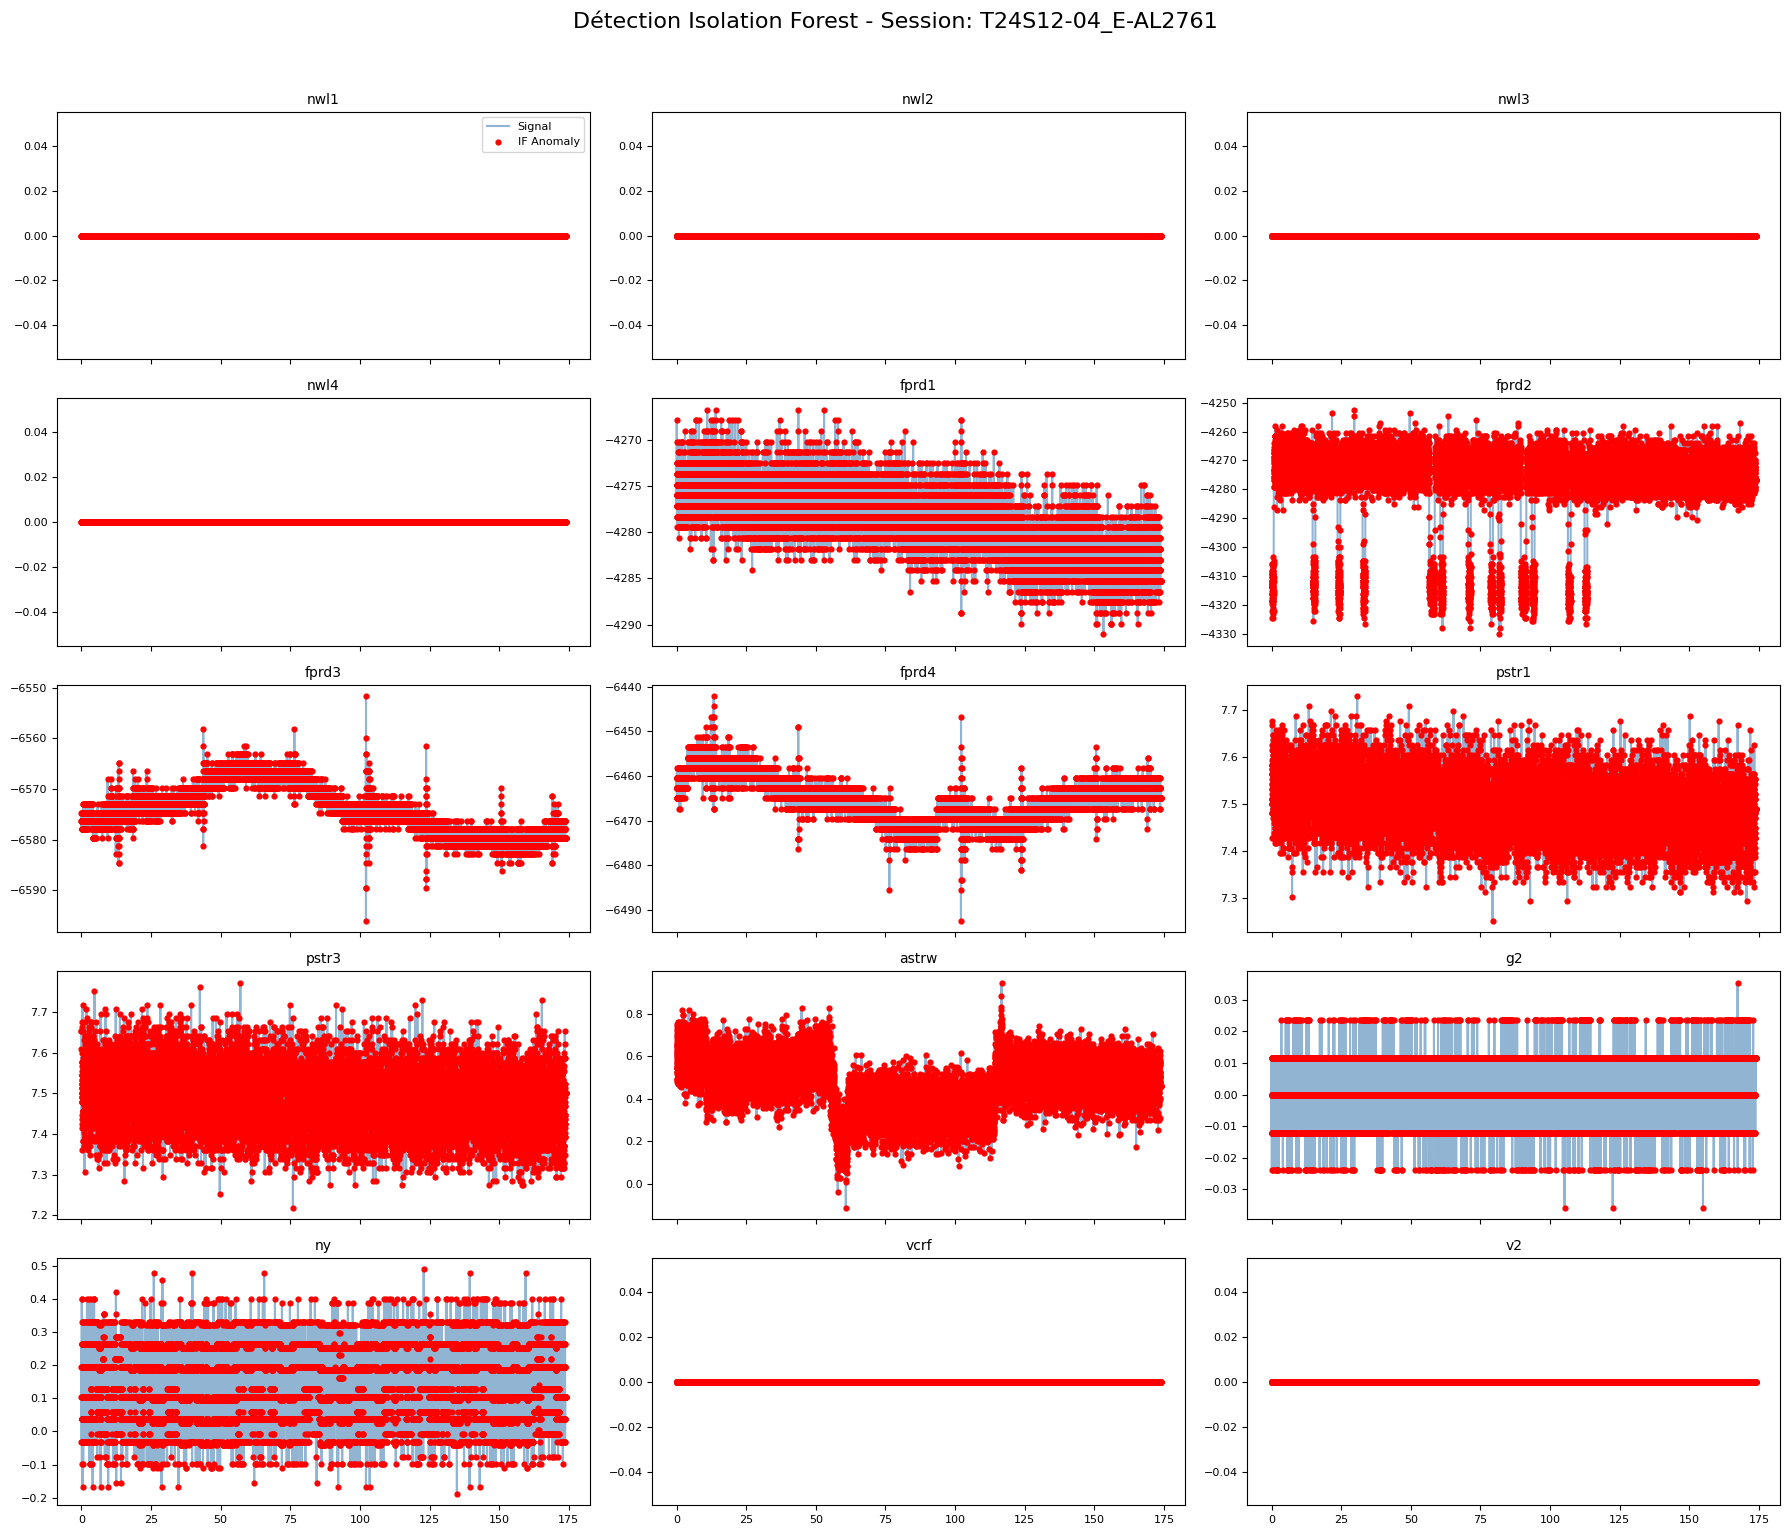

 Session : T24S12-04_E-AL2780
Detection rate : 1.68%


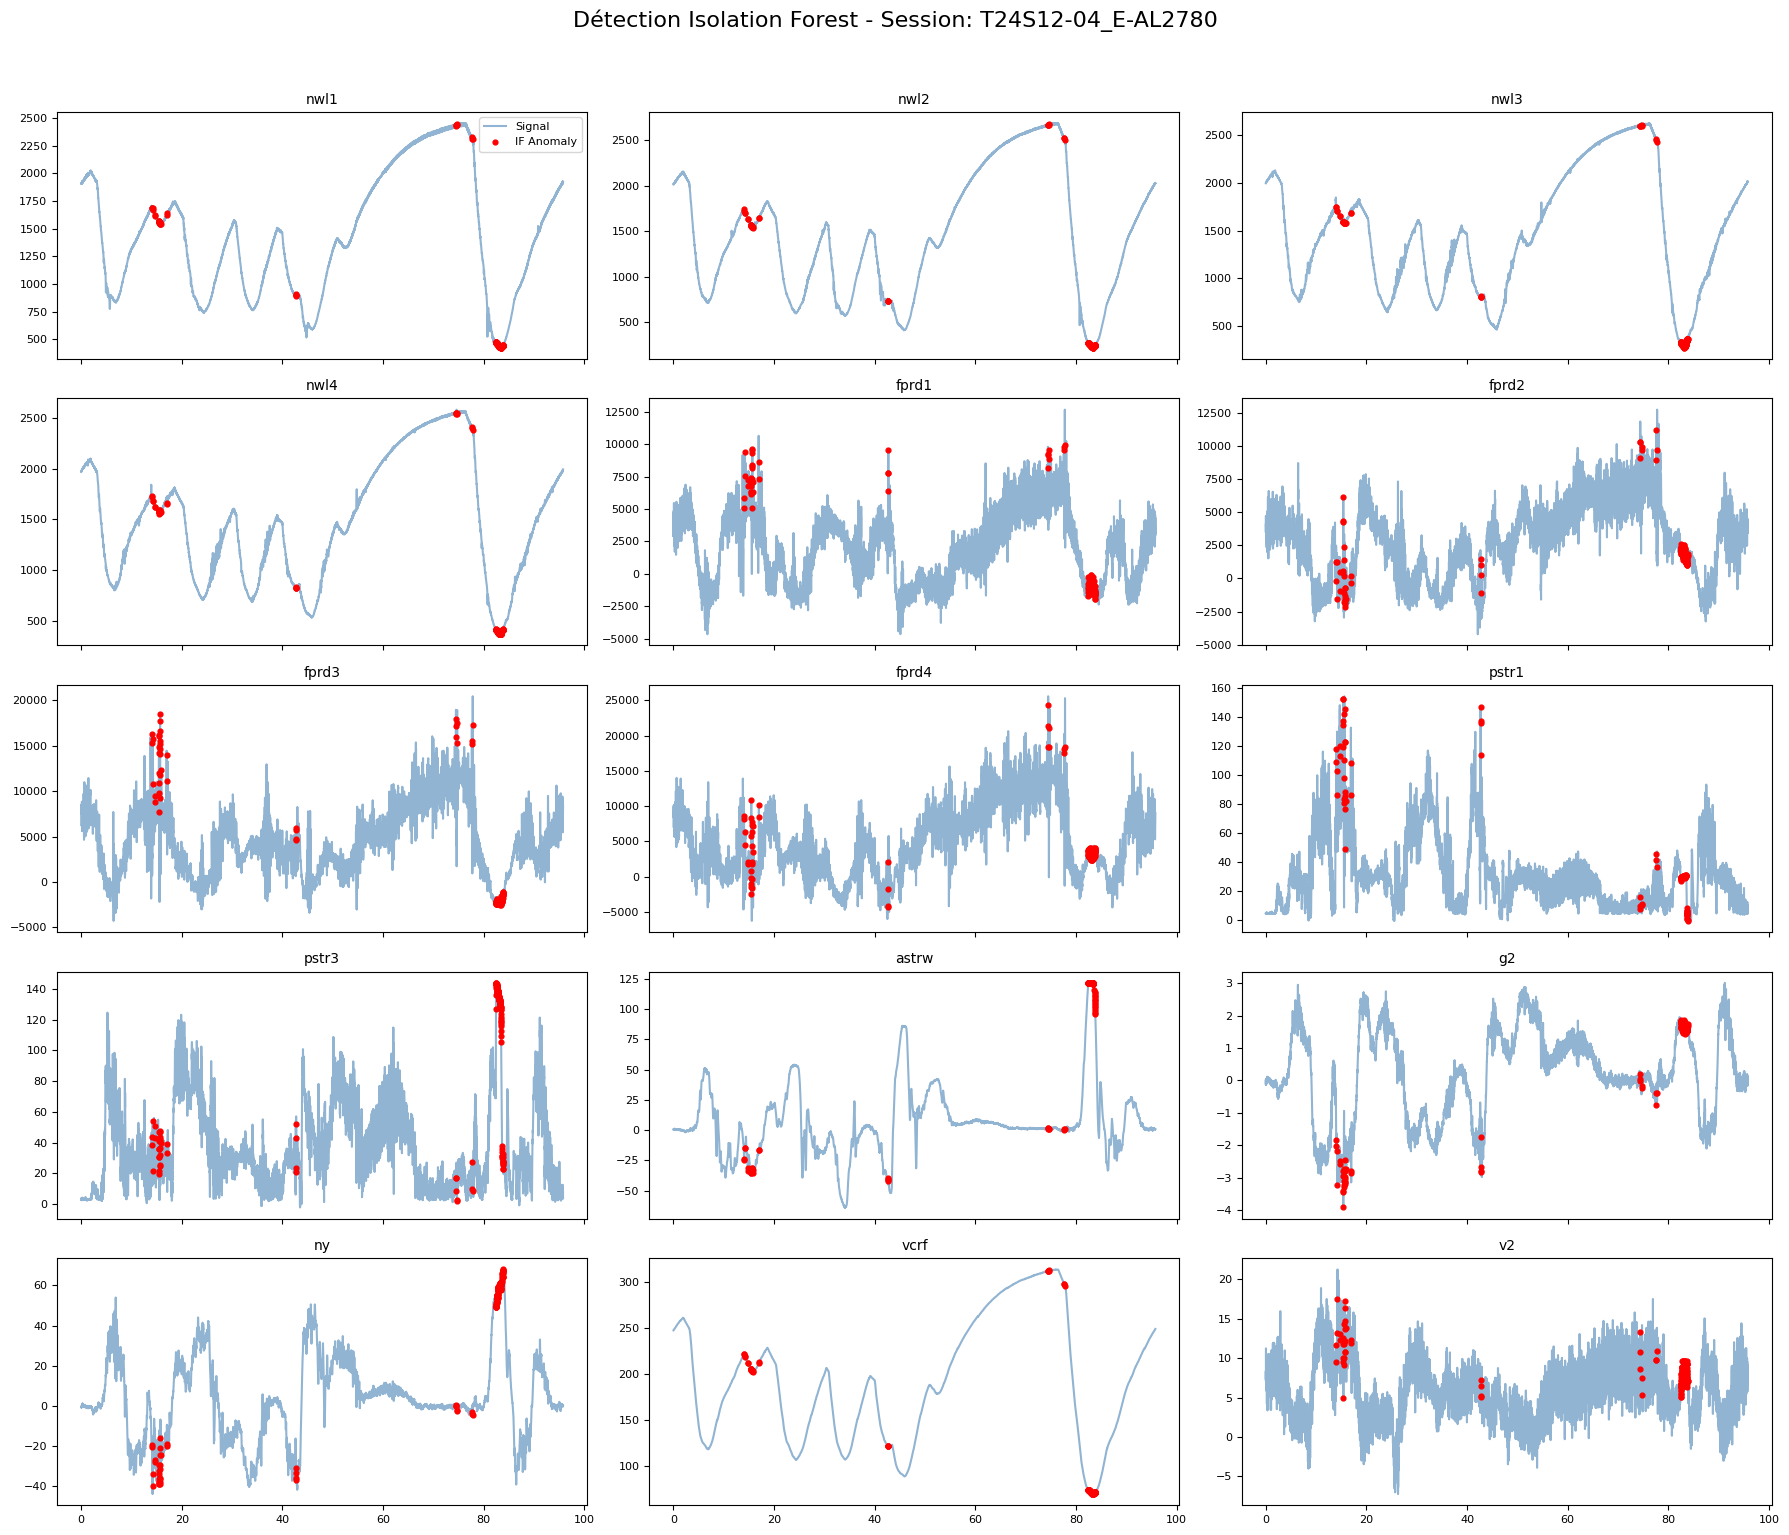

 Session : T24S12-04_E-AL2819
Detection rate : 100.00%


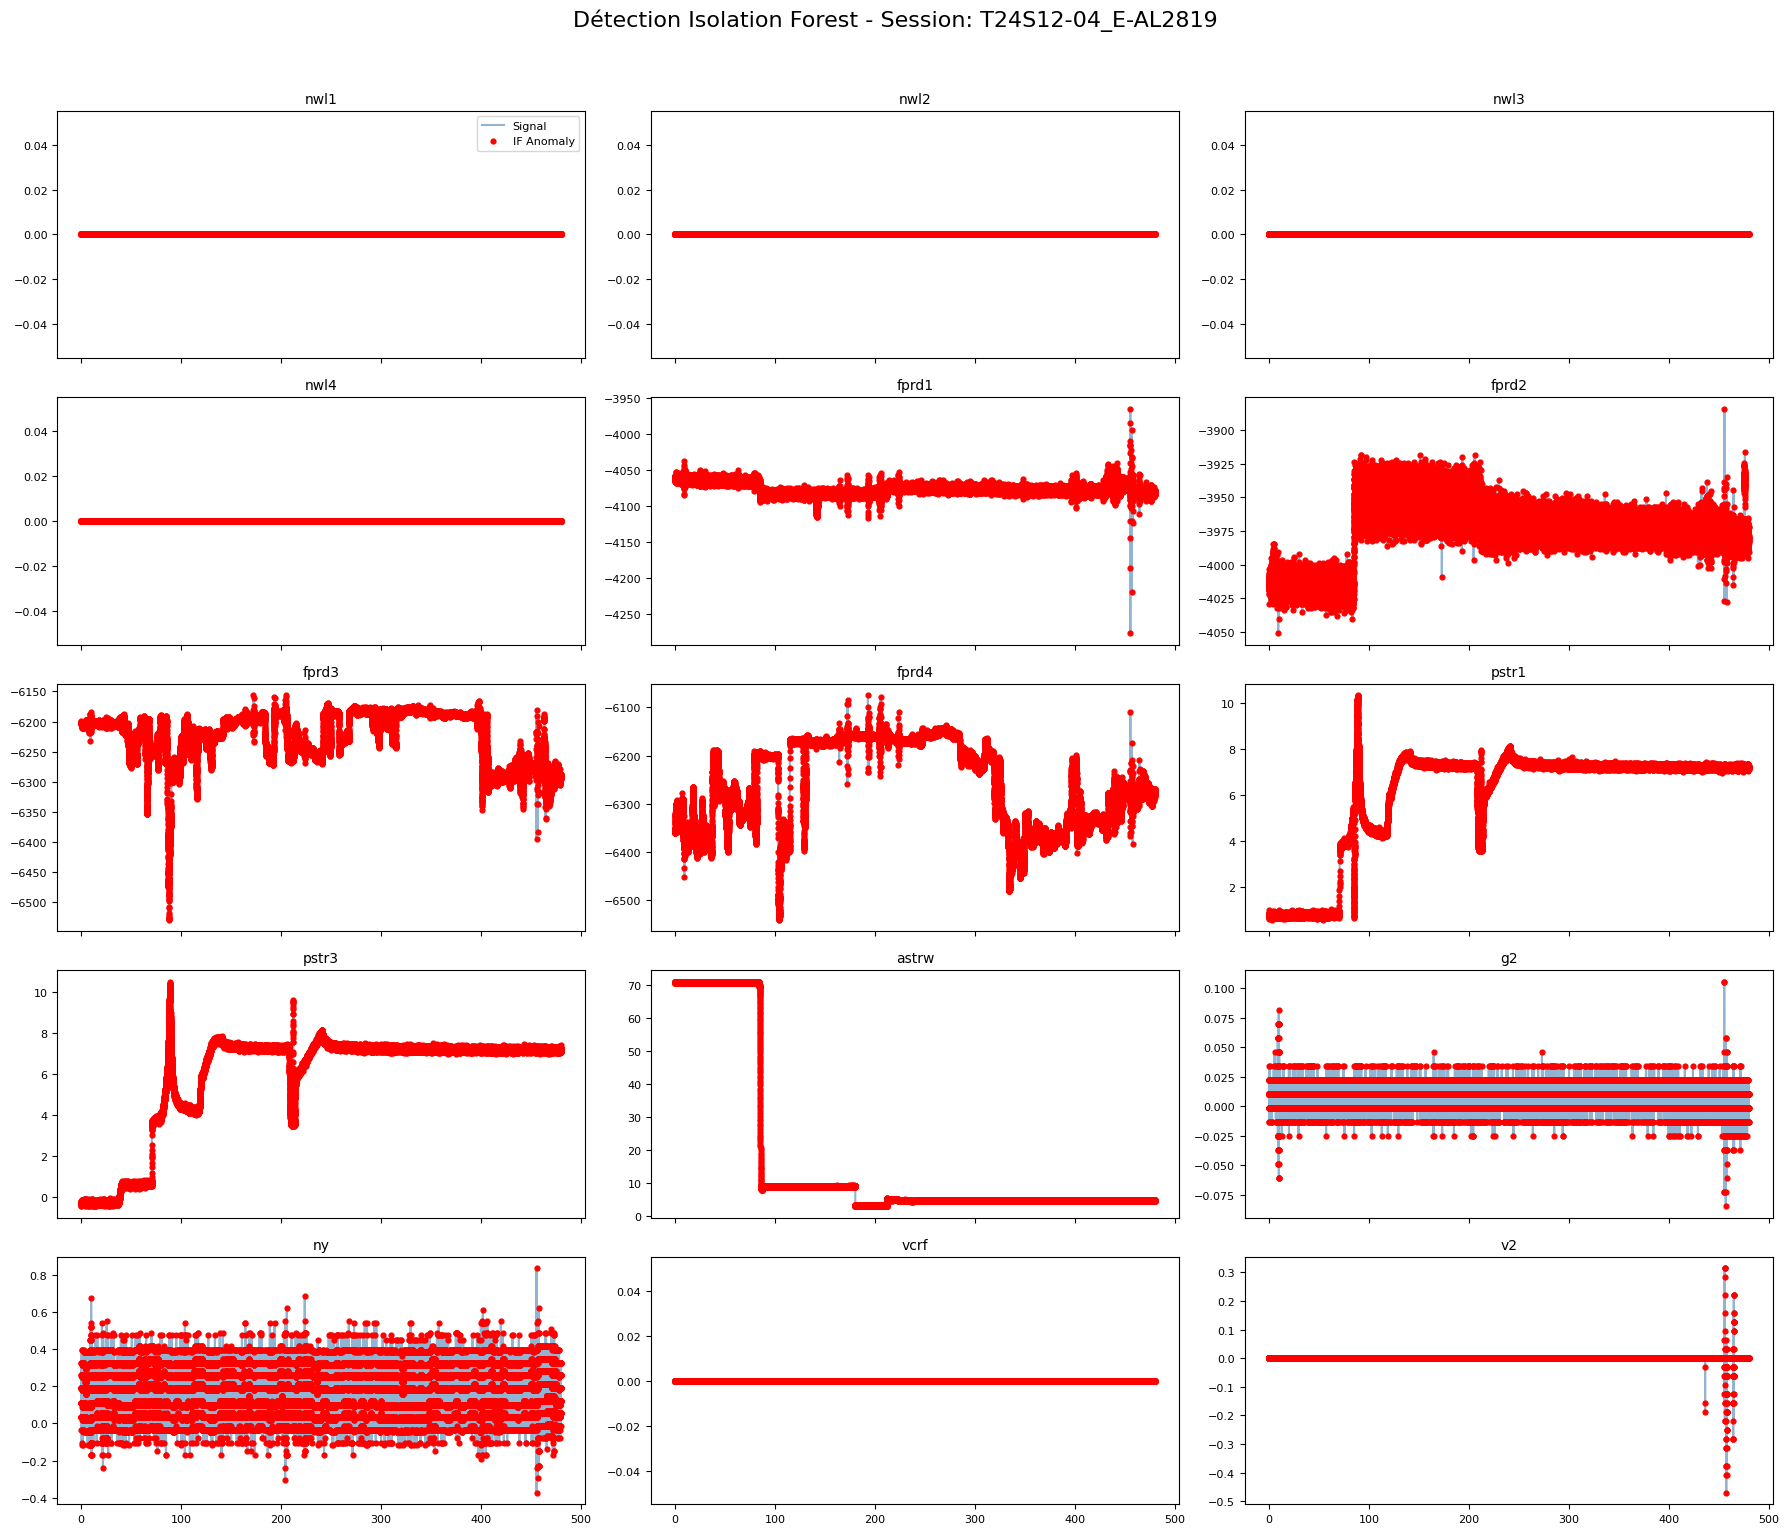

 Session : T24S12-04_E-AL2948
Detection rate : 0.00%


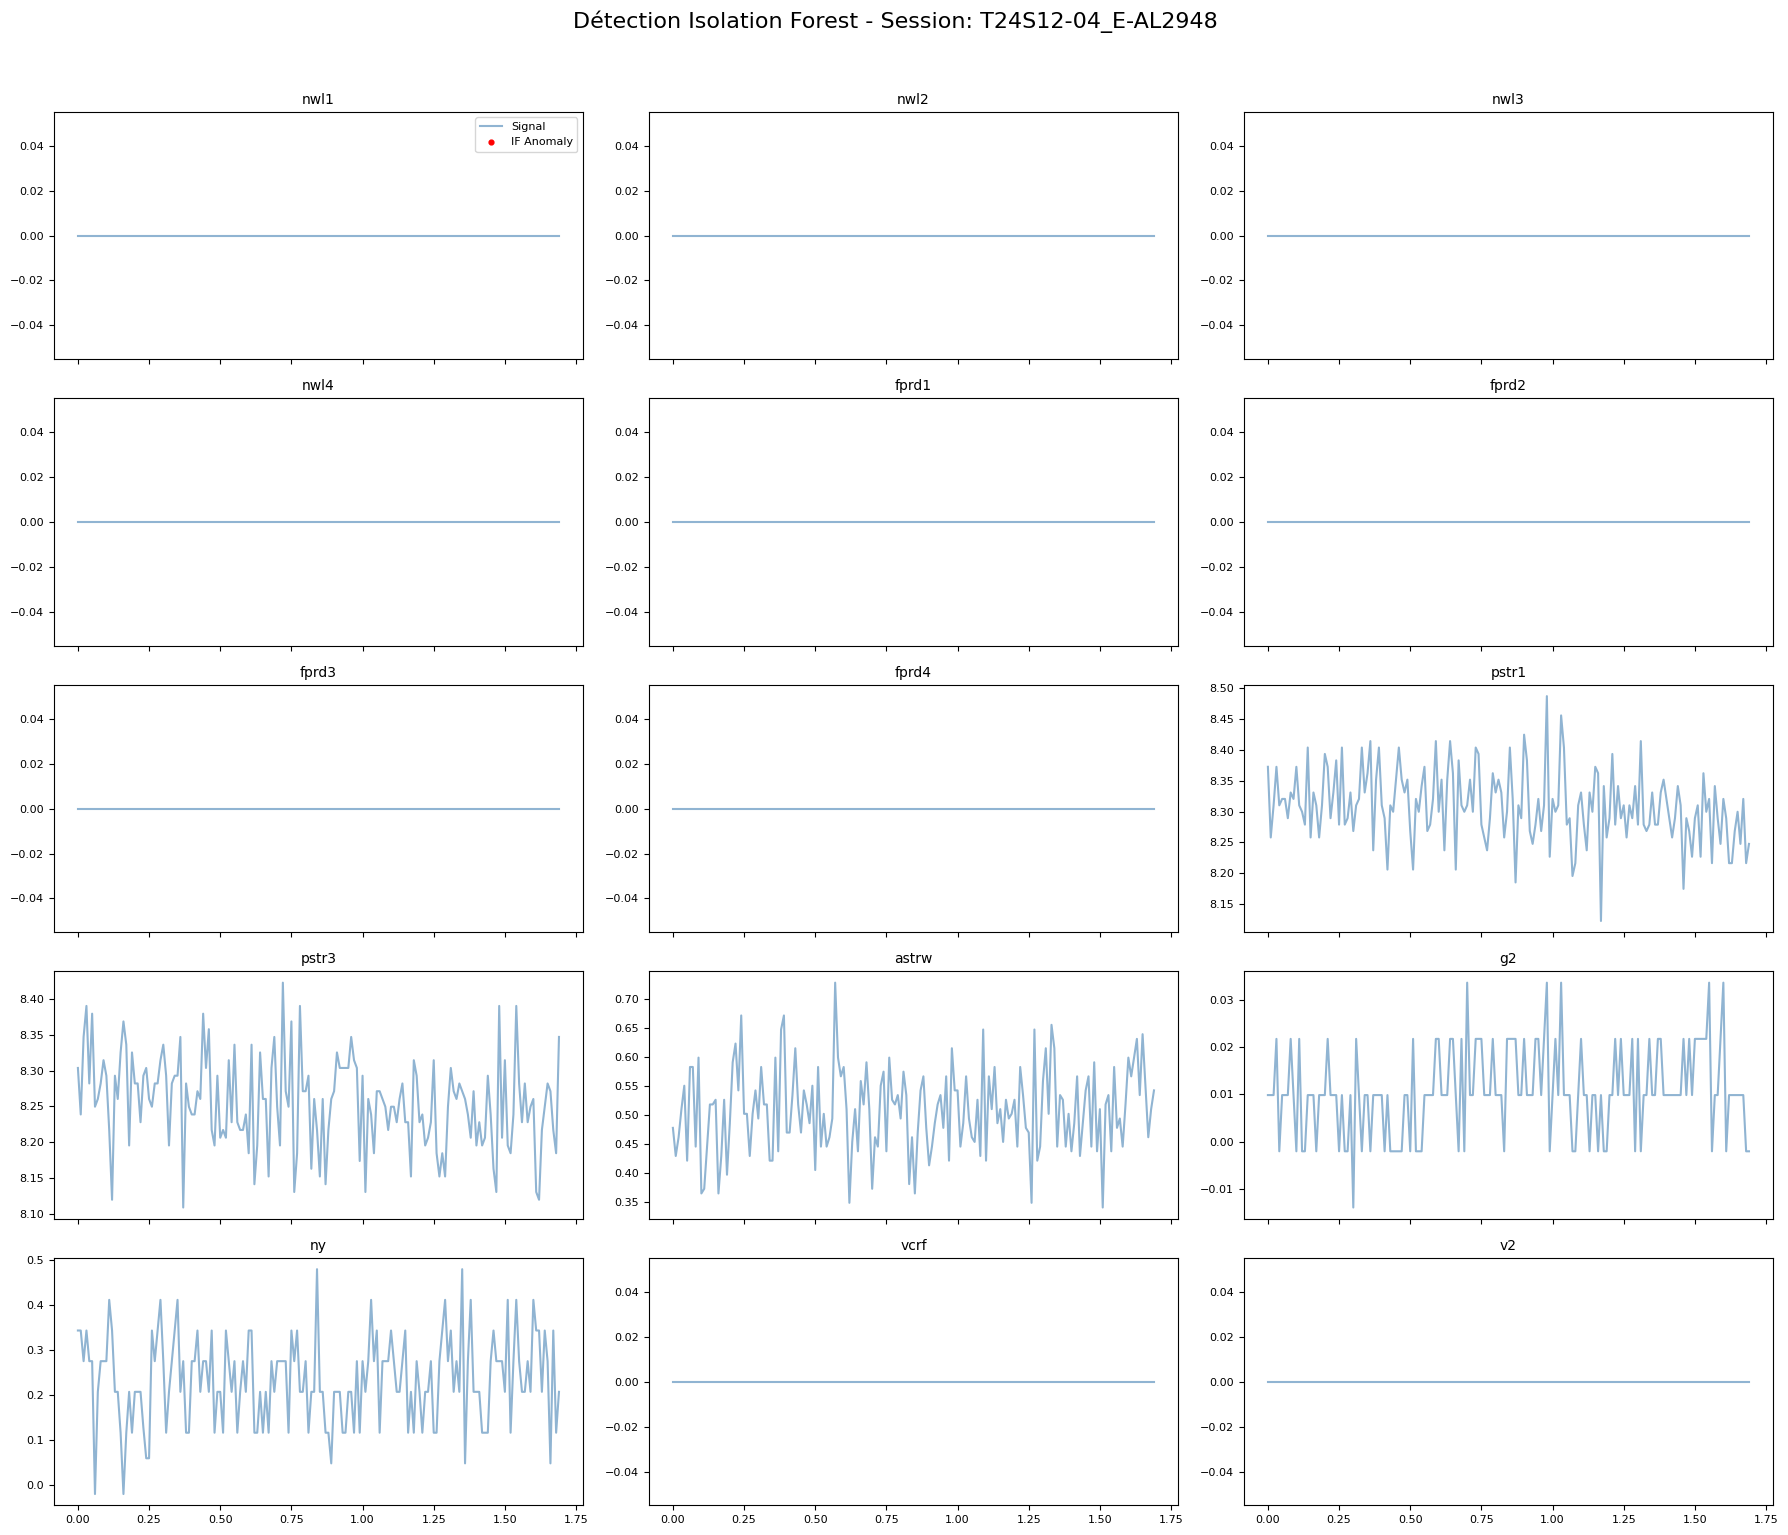

 Session : T24S12-04_E-AL3089
Detection rate : 48.38%


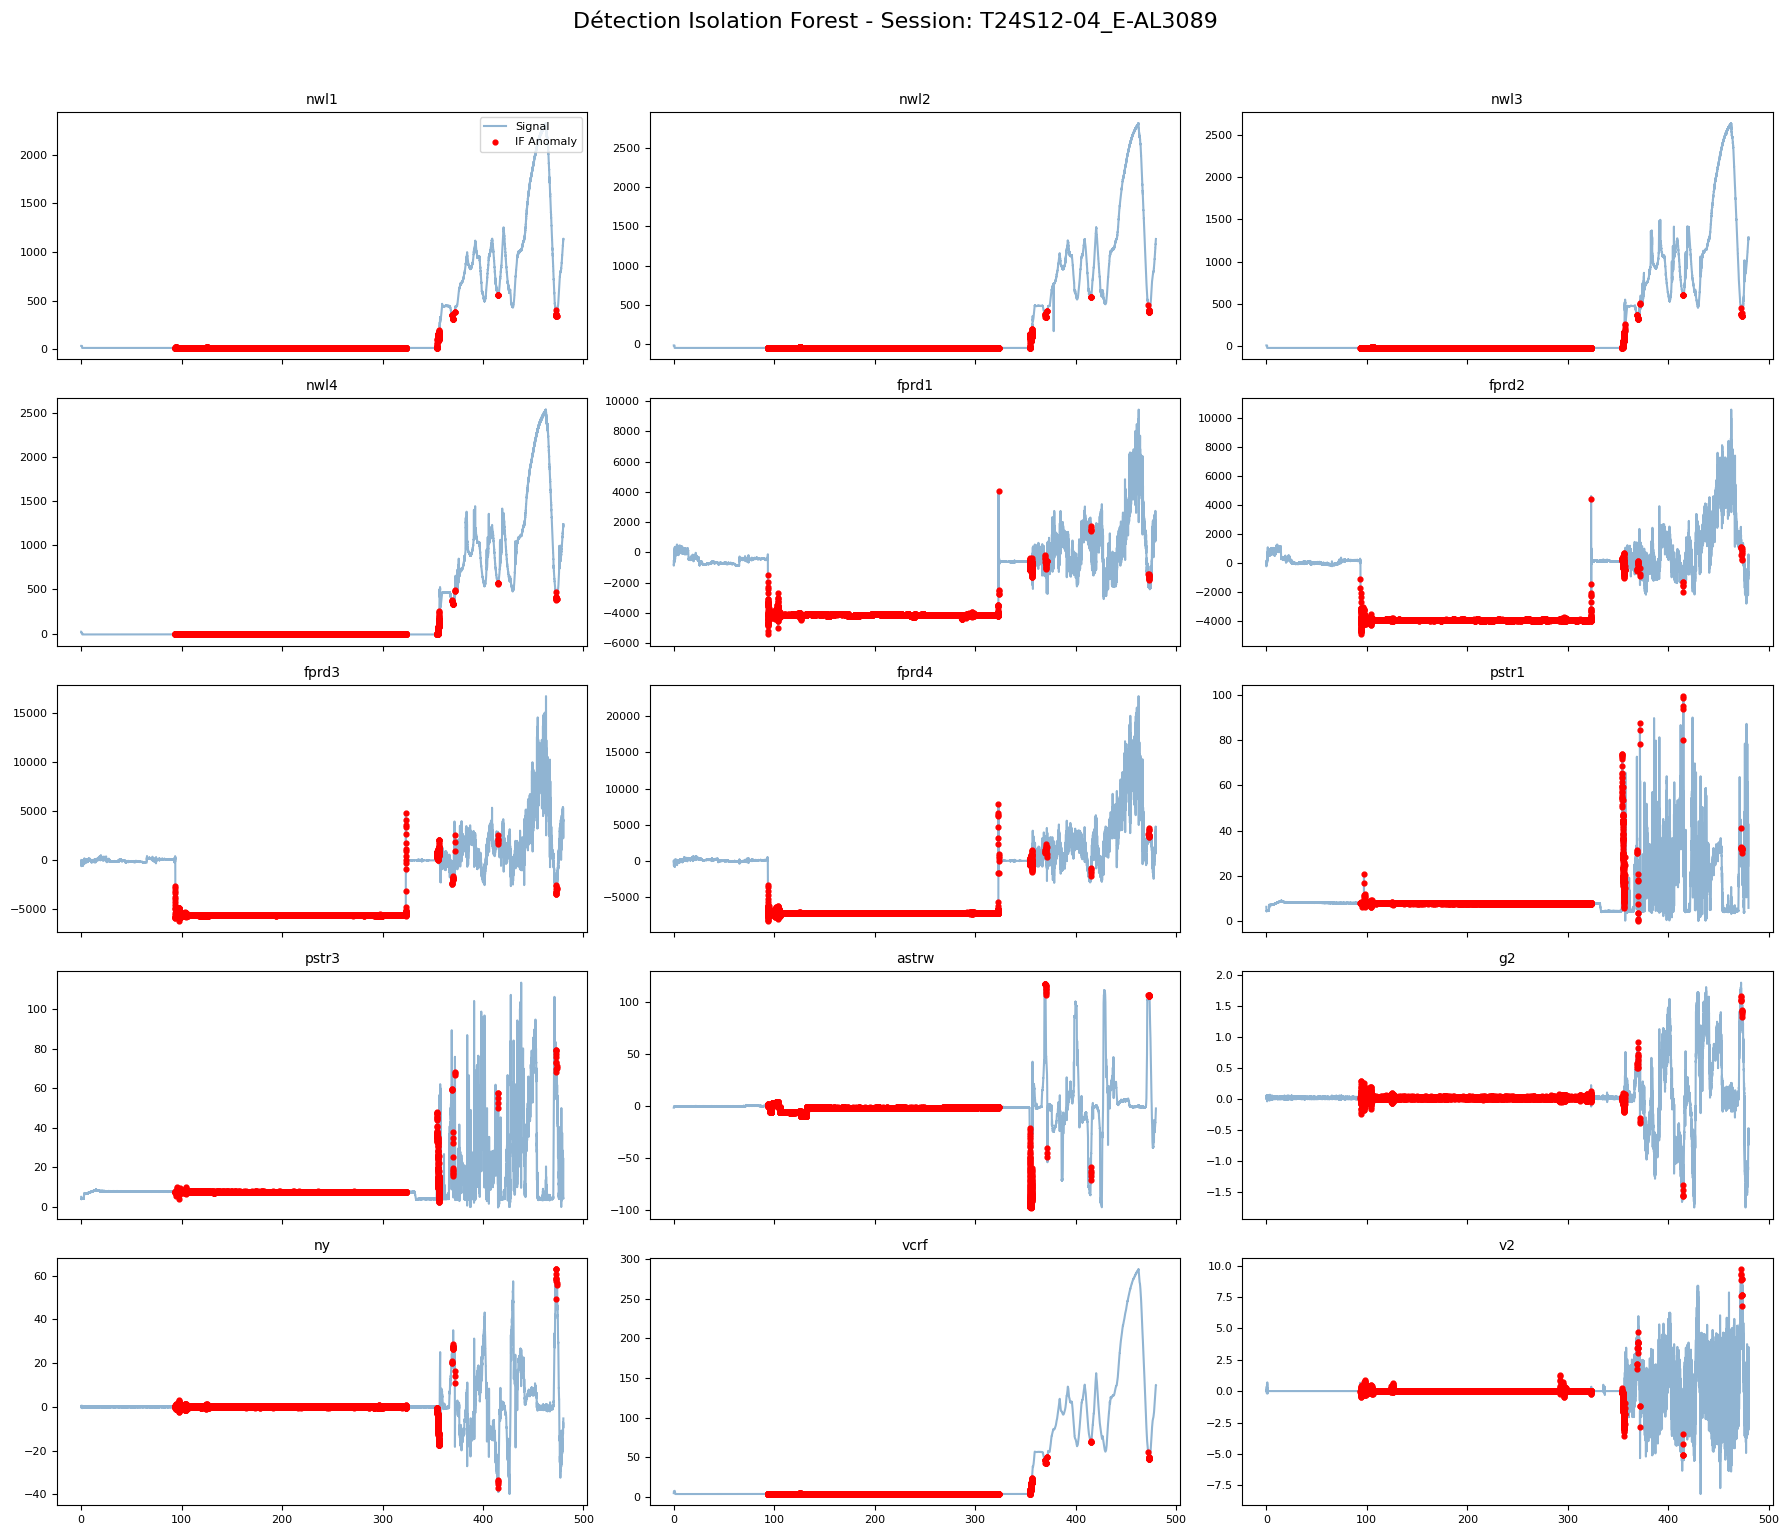

 Session : T24S12-04_E-AL3155
Detection rate : 100.00%


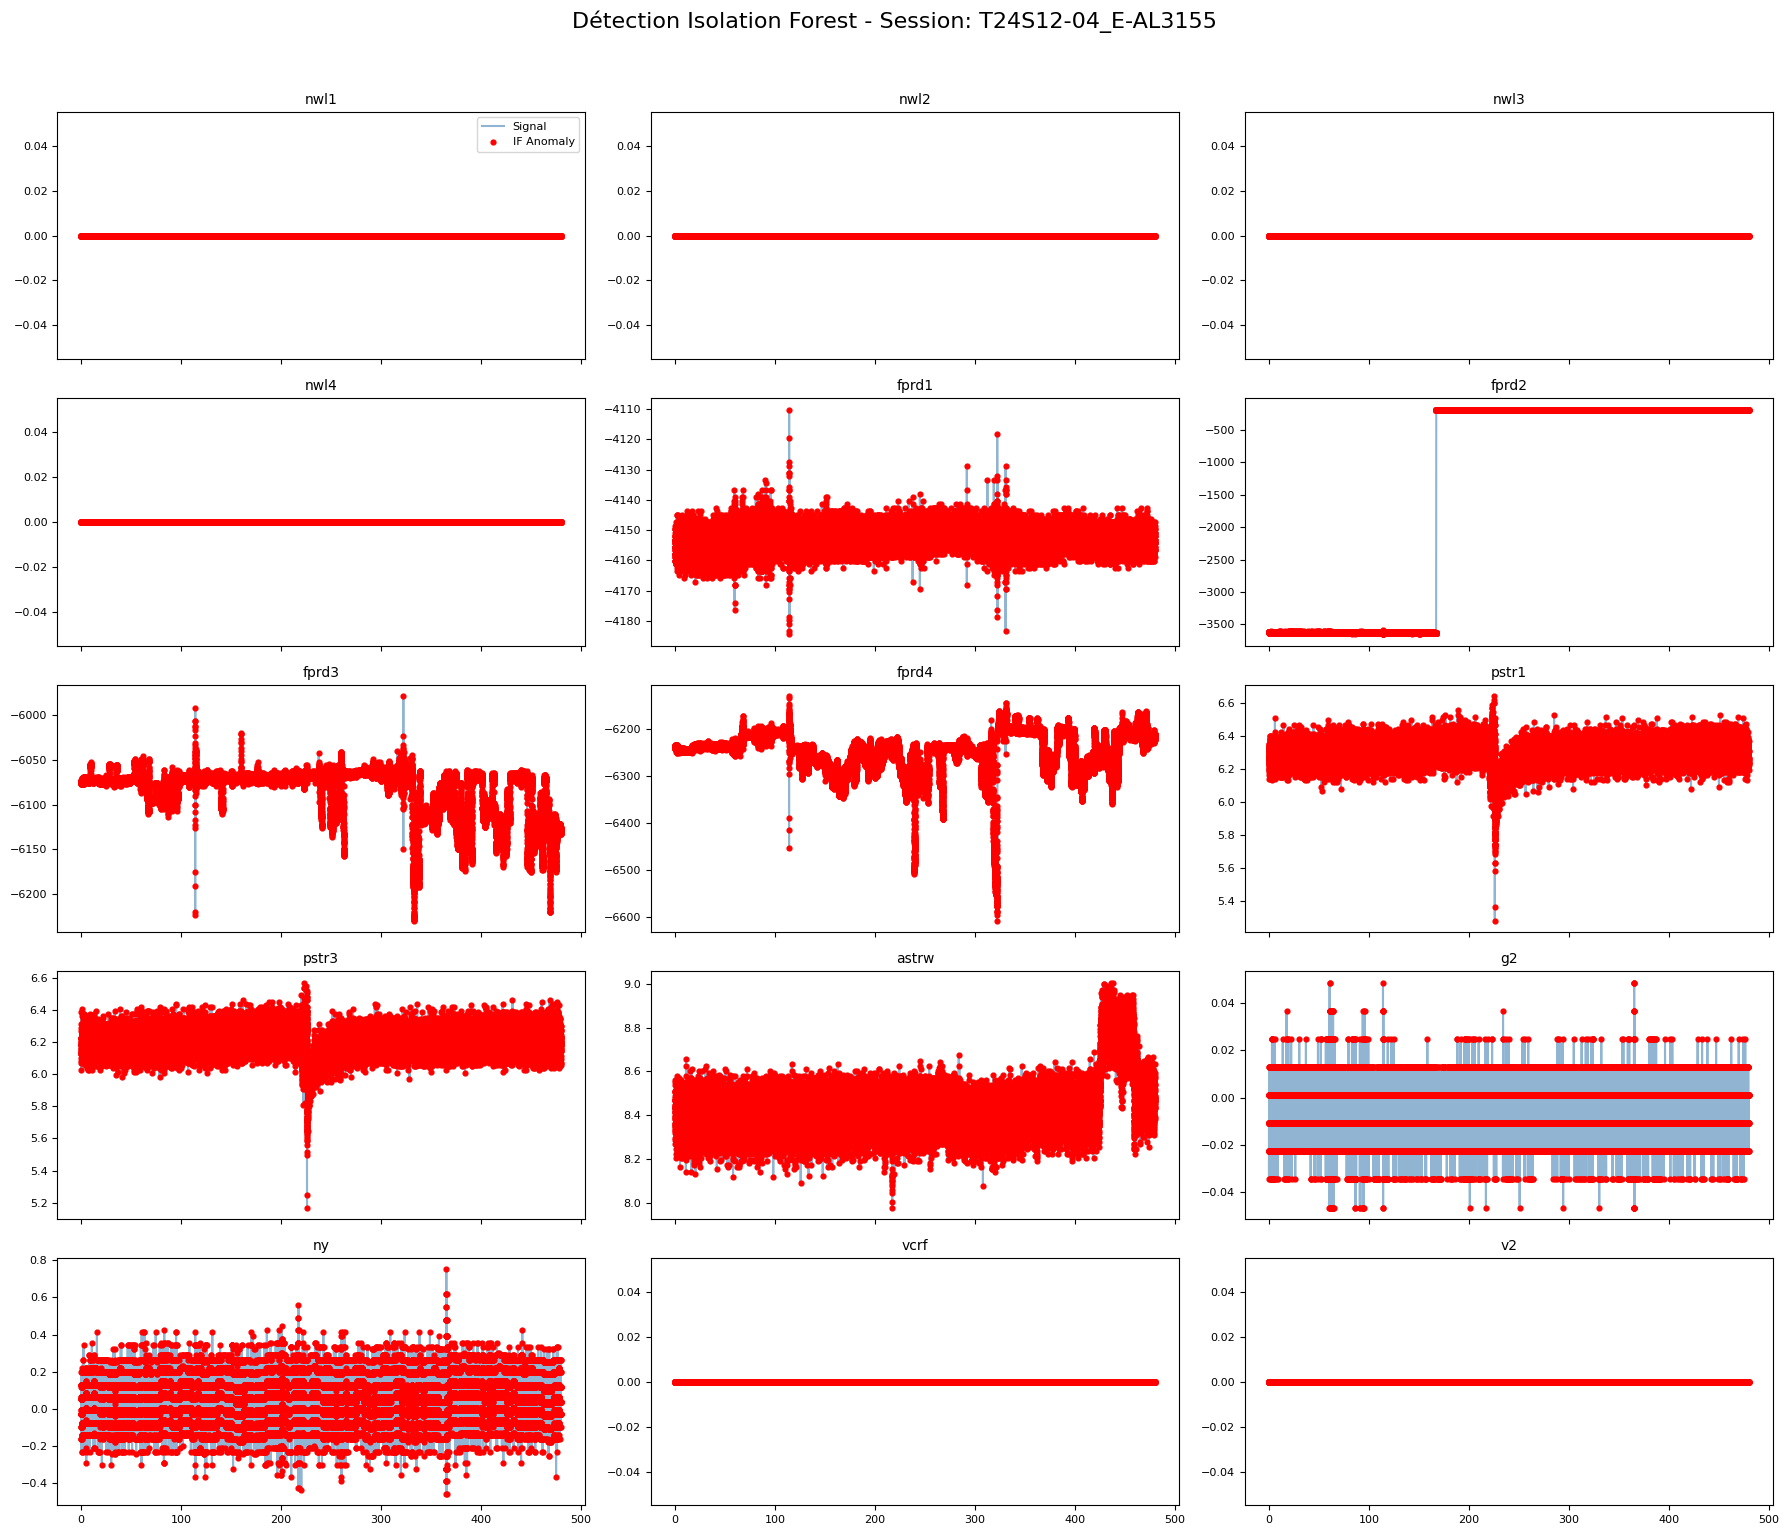

 Session : T24S12-04_E-AL3597
Detection rate : 100.00%


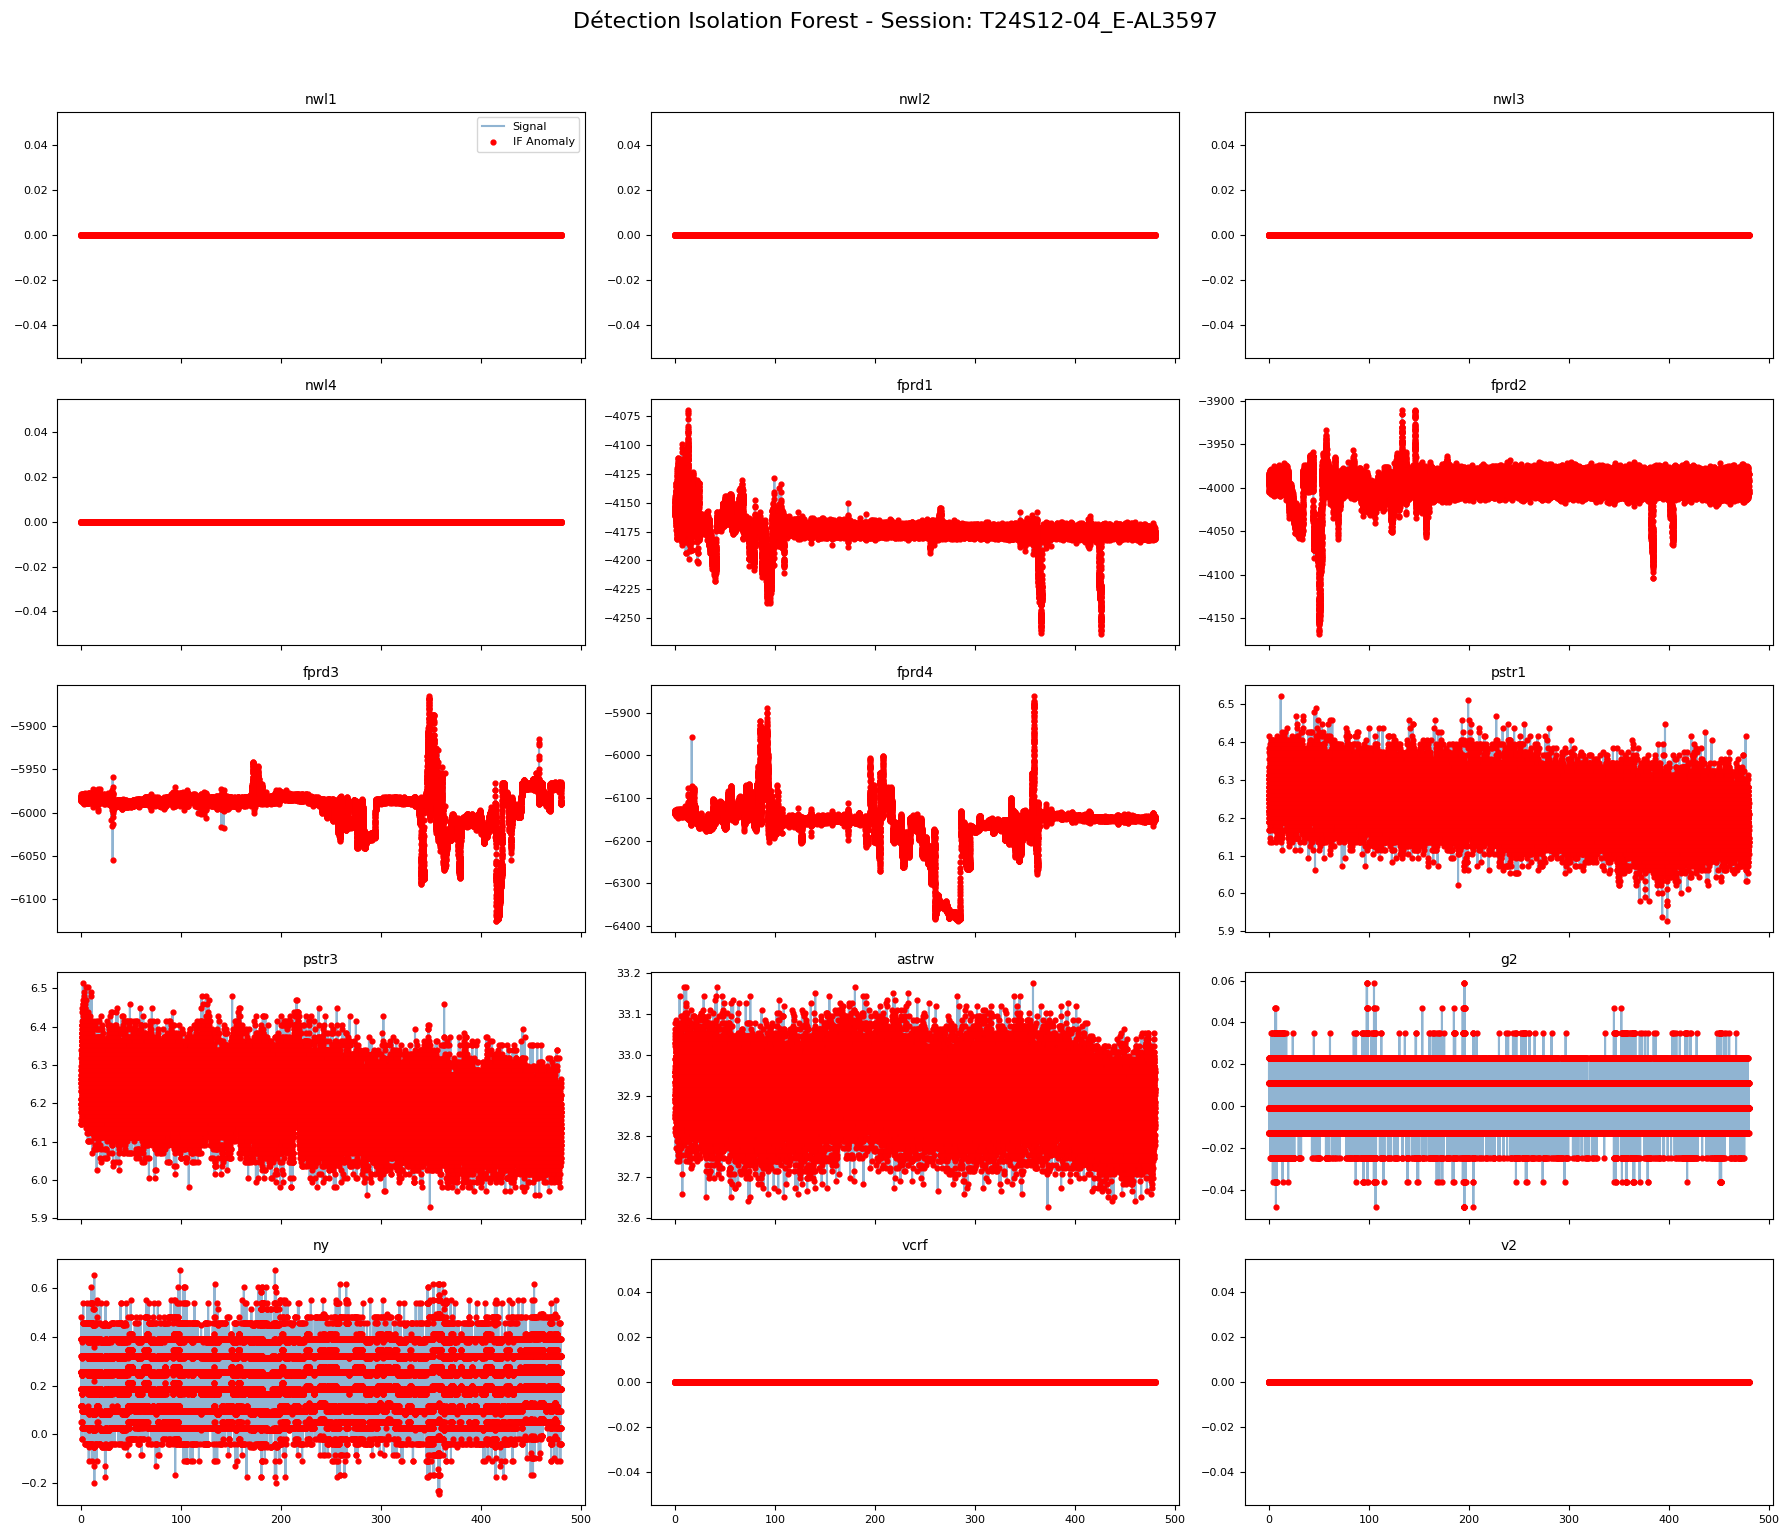

 Session : T24S12-04_E-AL3674
Detection rate : 67.77%


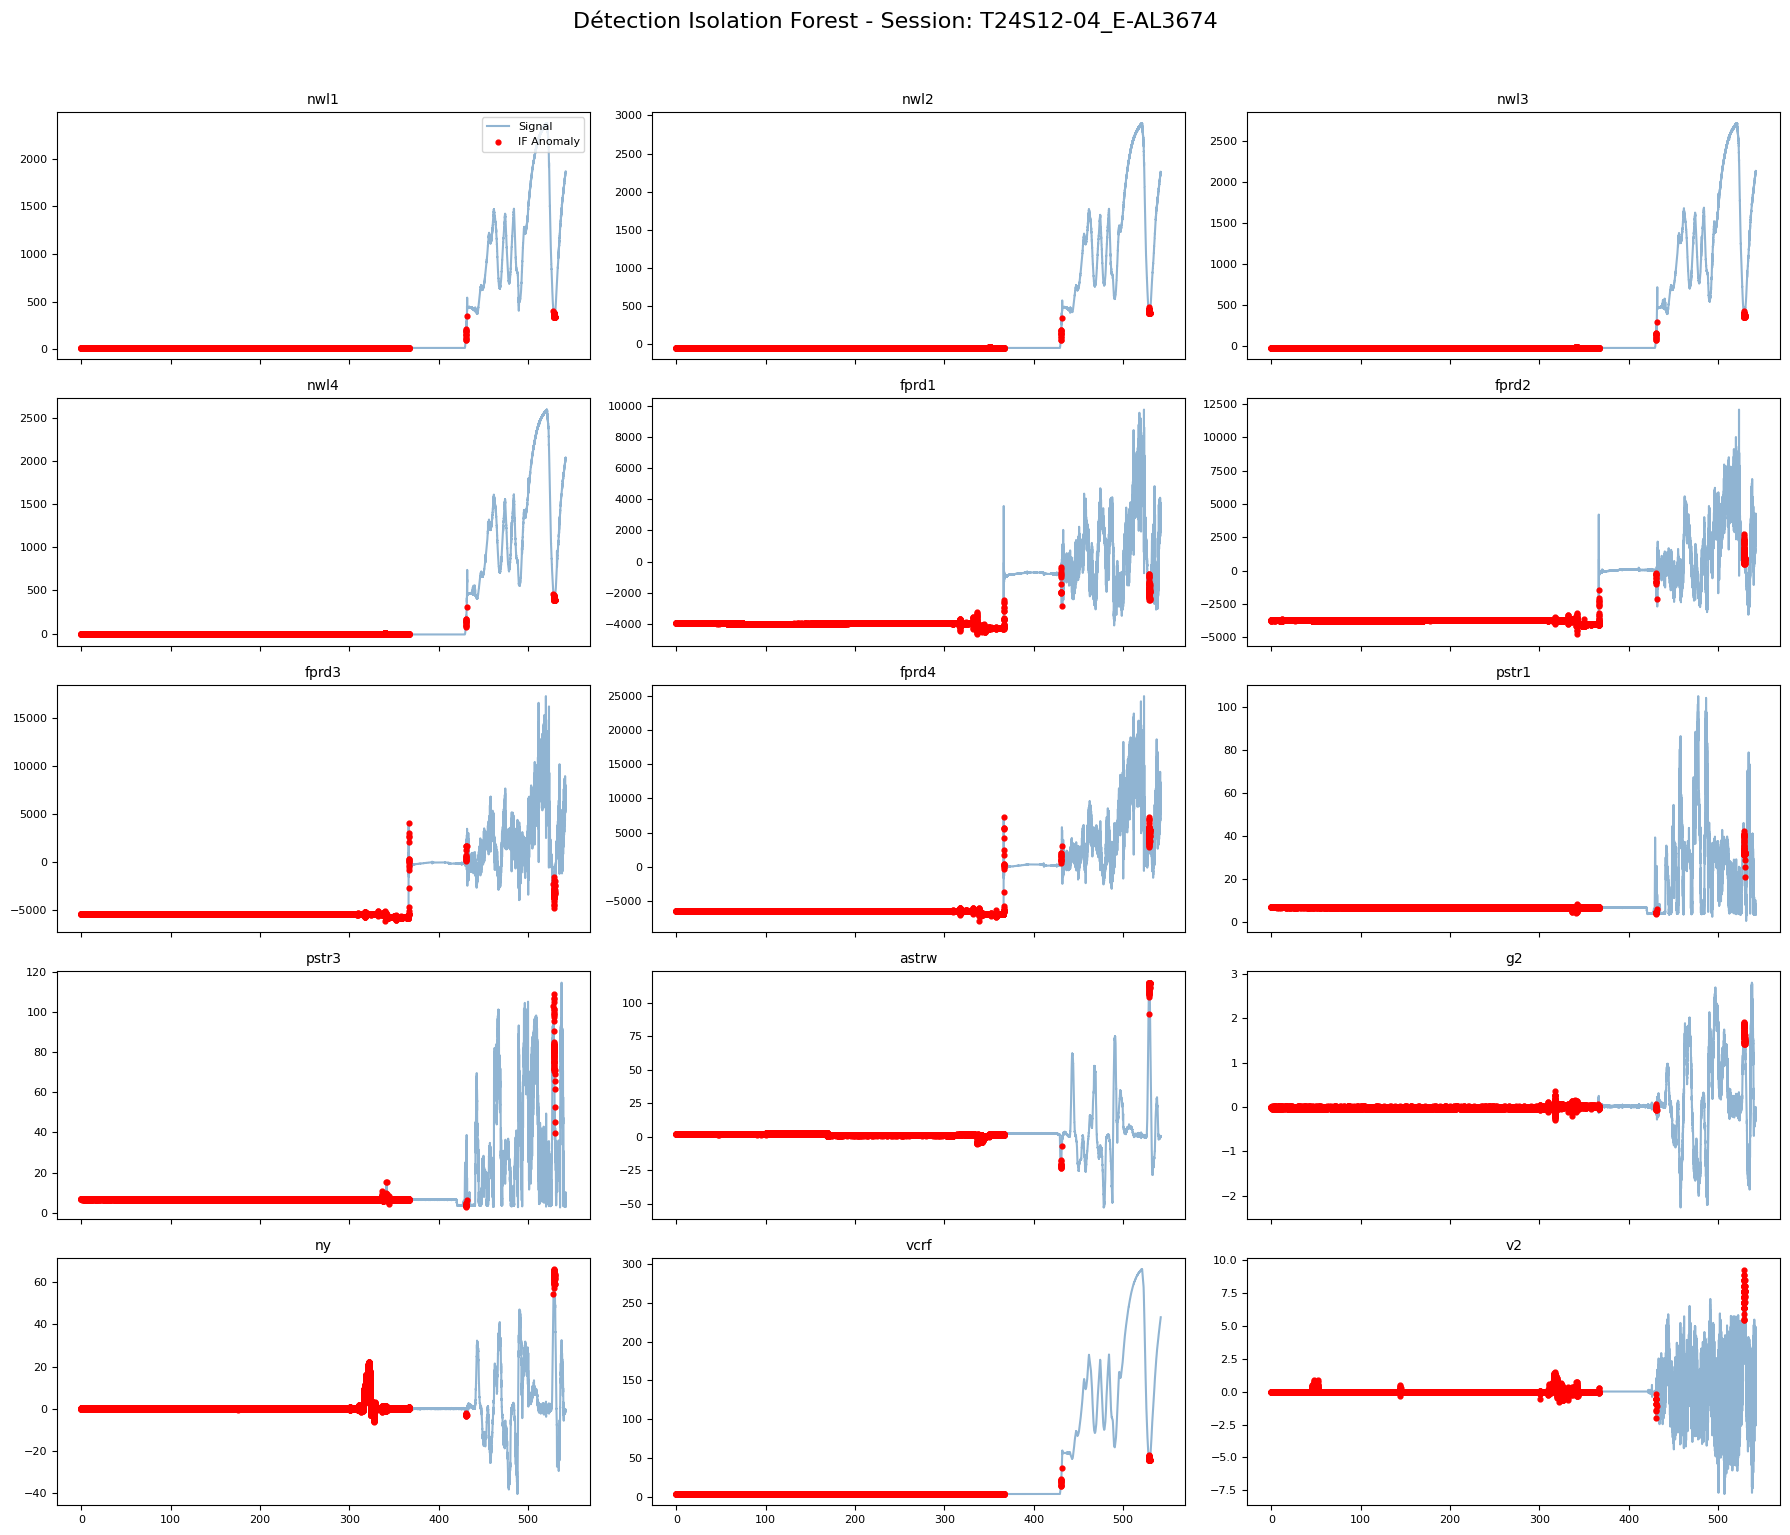

In [19]:
for name in session_anomaly:
    id_panne_complet = [k for k in data_dict.keys() if name in k][0]

    df_panne = data_dict[id_panne_complet].copy()
    df_panne = preprocessing.clean_dataframe(df_panne)
    results_panne = clf_if.predict_anomalies(df_panne)
    #Print the result
    print(f" Session : {name}")
    print(f"Detection rate : {results_panne['anomaly_detected'].mean() * 100:.2f}%")

    df_plot = results_panne.copy()
    anomaly_mask = df_plot['anomaly_detected'] == 1
    anomaly_times = df_plot.loc[anomaly_mask, 'time_real']

# Select only the sensors 
    cols_to_show = features[:15] 

    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 15), sharex=True)
    axes = axes.flatten()

    for i, col in enumerate(cols_to_show):
        ax = axes[i]
        
        # Draw the original signal
        ax.plot(df_plot['time_real'], df_plot[col], color='steelblue', alpha=0.6, label='Signal')

        # Overlay the anomaly points in red
        ax.scatter(
            anomaly_times,
            df_plot.loc[anomaly_mask, col],
            color='red',
            s=12,
            label='IF Anomaly',
            zorder=3
        )

        ax.set_title(f"{col}", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=8)
        if i == 0:
            ax.legend(loc="upper right", fontsize=8)


    plt.suptitle(f"Détection Isolation Forest - Session: {name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
#

The Isolation Forest algorithm yields strong results on sessions labeled as anomalous, successfully identifying significant deviations in sensor magnitudes. However, for a few specific sessions, the detection rate remains notably low.

Visual analysis of the plots suggests these sessions maintain a 'normal' signal shape but suffer from temporal shifts (time-lag). These deviations are likely not caused by mechanical failures, but by environmental changes (such as rain, road conditions, or different driving styles) that delay the vehicle's response by a few seconds.

Since Isolation Forest is a point-based (point-wise) outlier detector, it treats each points independently. It struggles to capture these 'contextual anomalies' because at any given second, the sensor value remains within a plausible physical range. To effectively distinguish between a true structural fault and a simple environmental shift, a sequence-based model like a GRU-Autoencoder is more robust, as it learns the temporal dependencies and the global dynamics of the system rather than just the distribution of independent points.